# AIVLE스쿨 2차 미니프로젝트: 신규 아파트 주차 수요 예측

<img src = "https://github.com/Jangrae/img/blob/master/parking.png?raw=true" width=800, align="left"/>

# 단계 2: 탐색적 데이터 분석

## [미션]

단계1 에서 생성한 데이터에 대해서 탐색적 분석을 수행합니다.

1) 단변량 분석
    - 숫자형, 범주형 변수에 맞게 데이터를 탐색하며 비즈니스적 의미를 파악합니다.
2) 이변량 분석
    - 숫자형 변수 → 실차량수 상관관계를 분석합니다.    
    - 범주형 변수 → 실차량수 관계를 분석합니다.
3) 전처리(추가)
    - 범주형 변수 중에는 범줏값 개수가 적은 범주들은 유사한 범주끼리 묶어 봅니다.
    - 불필요한 변수를 제거합니다.

## 1. 환경설정

### (1) 로컬 수행(Anaconda)

- project 폴더에 필요한 파일들을 넣고, 본 파일을 열었다면, 별도 경로 지정이 필요하지 않습니다.

In [280]:
# 기본 경로
path = ''

### (4) 라이브러리 불러오기

In [283]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import scipy.stats as spst

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

In [285]:
# 표시 형식 변경
pd.set_option('display.float_format', '{:.4f}'.format)

### (5) 데이터 불러오기

- joblib.dump() 함수를 사용해 이전에 저장했던 base_data1.pkl 파일을 읽어옵니다.
- 읽어온 데이터를 apart 데이터프레임으로 선언합니다.

#### 1) 데이터 불러오기

In [419]:
# 파일 불러오기
apart = joblib.load(path+'base_data1.pkl')

#### 2) 기본 정보 조회

In [298]:
apart.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
0,C0001,78,서울,2013,계단식,개별가스난방,전체동 설치,109,6023.7683,0,78,0,0,57598307.6923,645243.8462
1,C0002,35,서울,2013,복도식,개별가스난방,전체동 설치,35,1569.1668,35,0,0,0,63062000.0000,464533.7143
2,C0003,88,서울,2013,계단식,개별가스난방,전체동 설치,88,7180.1396,0,88,0,0,72190000.0000,586540.0000
3,C0004,477,서울,2014,복도식,지역난방,전체동 설치,943,47058.9273,0,150,216,111,91584727.4633,877880.2725
4,C0006,15,서울,2013,복도식,개별가스난방,전체동 설치,21,543.0268,15,0,0,0,54463150.0000,330212.0000


In [300]:
apart.tail()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
340,C0354,1485,대전충남,1993,복도식,중앙난방,전체동 설치,298,64622.2500,1479,6,0,0,6983391.8644,96514.8949
341,C1354,1386,대전충남,1993,복도식,중앙가스난방,전체동 설치,258,57616.8100,1369,17,0,0,6079848.0176,84027.5184
342,C0356,956,경기,1994,복도식,지역가스난방,전체동 설치,243,37398.7200,956,0,0,0,9931000.0000,134540.0000
343,C0358,120,강원,2020,복도식,개별가스난방,전체동 설치,47,5581.8024,120,0,0,0,2476850.0000,49271.0000
344,C0359,447,대구경북,1994,복도식,중앙유류난방,전체동 설치,78,19383.4100,447,0,0,0,7792666.6667,127053.3333


In [302]:
apart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   단지코드      345 non-null    object 
 1   총세대수      345 non-null    int64  
 2   지역        345 non-null    object 
 3   준공연도      345 non-null    int64  
 4   건물형태      345 non-null    object 
 5   난방방식      345 non-null    object 
 6   승강기설치여부   345 non-null    object 
 7   실차량수      345 non-null    int64  
 8   총면적       345 non-null    float64
 9   면적10_40   345 non-null    int64  
 10  면적40_60   345 non-null    int64  
 11  면적60_80   345 non-null    int64  
 12  면적80_200  345 non-null    int64  
 13  임대보증금     345 non-null    float64
 14  임대료       345 non-null    float64
dtypes: float64(3), int64(7), object(5)
memory usage: 40.6+ KB


## 2. 기본 분석

- 기술통계정보, 결측치 확인 등 기본 분석을 수행합니다.

In [305]:
apart.describe()

,총세대수,준공연도,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
count,345.0000,345.0000,345.0000,345.0000,345.0000,345.0000,345.0000,345.0000,345.0000,345.0000
mean,546.7594,2007.7130,555.4319,37282.6620,215.3507,280.3449,18.7478,34.5159,23514575.0251,196173.7917
std,432.3595,7.2610,374.6405,29588.1979,295.4027,320.6694,90.8147,116.9759,21926977.1488,157484.5103
min,1.0000,1992.0000,21.0000,68.9300,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,178.0000,2003.0000,258.0000,11293.8321,0.0000,0.0000,0.0000,0.0000,12117000.0000,109413.1429
50%,491.0000,2008.0000,498.0000,32190.3600,100.0000,168.0000,0.0000,0.0000,18635710.5788,172830.3586
75%,853.0000,2013.0000,822.0000,56189.9796,343.0000,442.0000,0.0000,0.0000,27403840.5797,224706.1874
max,2289.0000,2022.0000,1657.0000,150126.8632,1630.0000,1445.0000,1002.0000,850.0000,186837974.2268,877880.2725


In [307]:
apart.isna().sum()

단지코드        0
총세대수        0
지역          0
준공연도        0
건물형태        0
난방방식        0
승강기설치여부     0
실차량수        0
총면적         0
면적10_40     0
면적40_60     0
면적60_80     0
면적80_200    0
임대보증금       0
임대료         0
dtype: int64

In [309]:
apart.corr(numeric_only=True)

,총세대수,준공연도,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
총세대수,1.0000,0.0854,0.7125,0.9273,0.6544,0.7047,0.0978,0.0212,0.1637,0.2030
준공연도,0.0854,1.0000,0.2873,0.1717,-0.0560,0.0227,0.2327,0.2300,0.3292,0.3204
실차량수,0.7125,0.2873,1.0000,0.8222,0.2019,0.5662,0.3402,0.3403,0.3592,0.3378
총면적,0.9273,0.1717,0.8222,1.0000,0.4042,0.6904,0.3125,0.3044,0.3488,0.3696
면적10_40,0.6544,-0.0560,0.2019,0.4042,1.0000,0.0773,-0.1509,-0.2157,-0.1482,-0.1059
면적40_60,0.7047,0.0227,0.5662,0.6904,0.0773,1.0000,-0.1557,-0.2347,0.0734,0.0887
면적60_80,0.0978,0.2327,0.3402,0.3125,-0.1509,-0.1557,1.0000,0.4574,0.3672,0.4427
면적80_200,0.0212,0.2300,0.3403,0.3044,-0.2157,-0.2347,0.4574,1.0000,0.4858,0.4211
임대보증금,0.1637,0.3292,0.3592,0.3488,-0.1482,0.0734,0.3672,0.4858,1.0000,0.8525
임대료,0.2030,0.3204,0.3378,0.3696,-0.1059,0.0887,0.4427,0.4211,0.8525,1.0000


## 3. 단변량 분석

- 주요 변수들을 연속형, 범주형으로 구분하여 데이터 분포를 살펴보며 비즈니스적인 의미를 파악합니다.
    - 연속형: '실차량수', '총세대수', '총면적', '준공연도', '임대료', '임대보증금'
    - 범주형: '지역', '건물형태', '난방방식', '승강기설치여부'
- 전용면적구간은 pd.melt() 함수를 사용해 pivot을 해제한 후 분석합니다.

### (1) 연속형 변수

- 대상: '실차량수', '총세대수', '총면적', '준공연도', '임대료', '임대보증금'
- 기술통계, Histogram, Boxplot 등을 사용해 데이터 분포를 파악합니다.
- 반복되는 코드는 함수를 만들어 사용하면 편리합니다.

In [313]:
# 함수 만들기
def cont_uni(col_name):
    plt.figure(figsize=(10,8))
    plt.subplot(2,1,1)
    sns.histplot(x=col_name, data=apart)
    plt.subplot(2,1,2)
    plt.boxplot(x=apart[col_name], vert=False)
    plt.tight_layout()
    plt.show()

#### 1) 실차량수

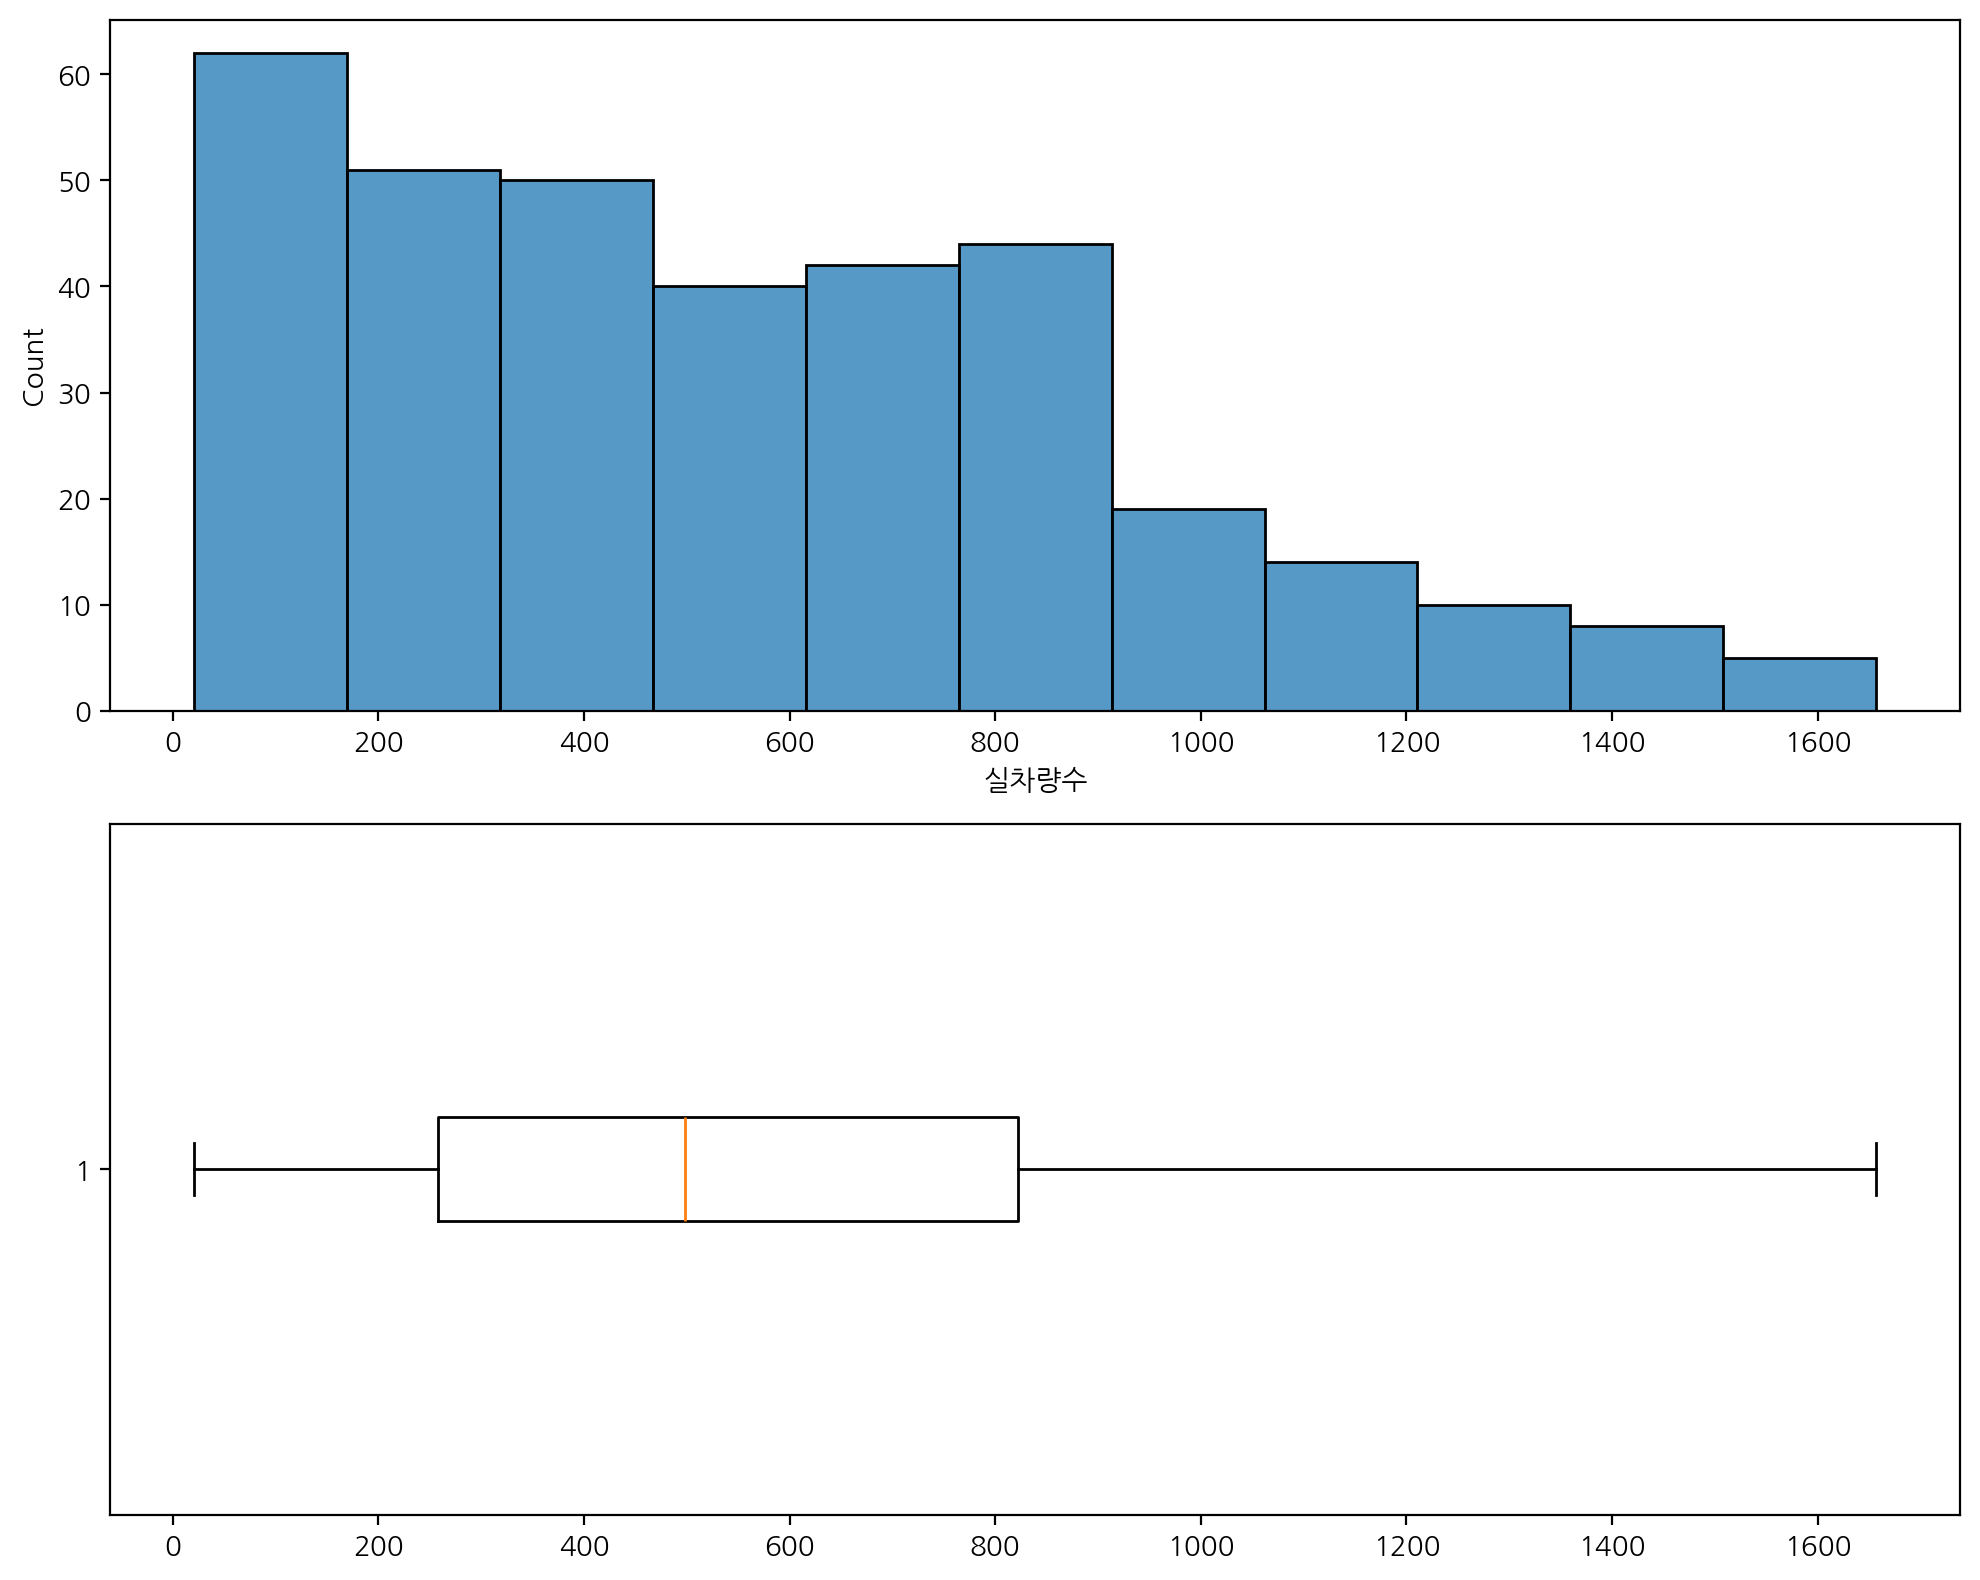

In [316]:
cont_uni('실차량수')

#### 2) 총세대수

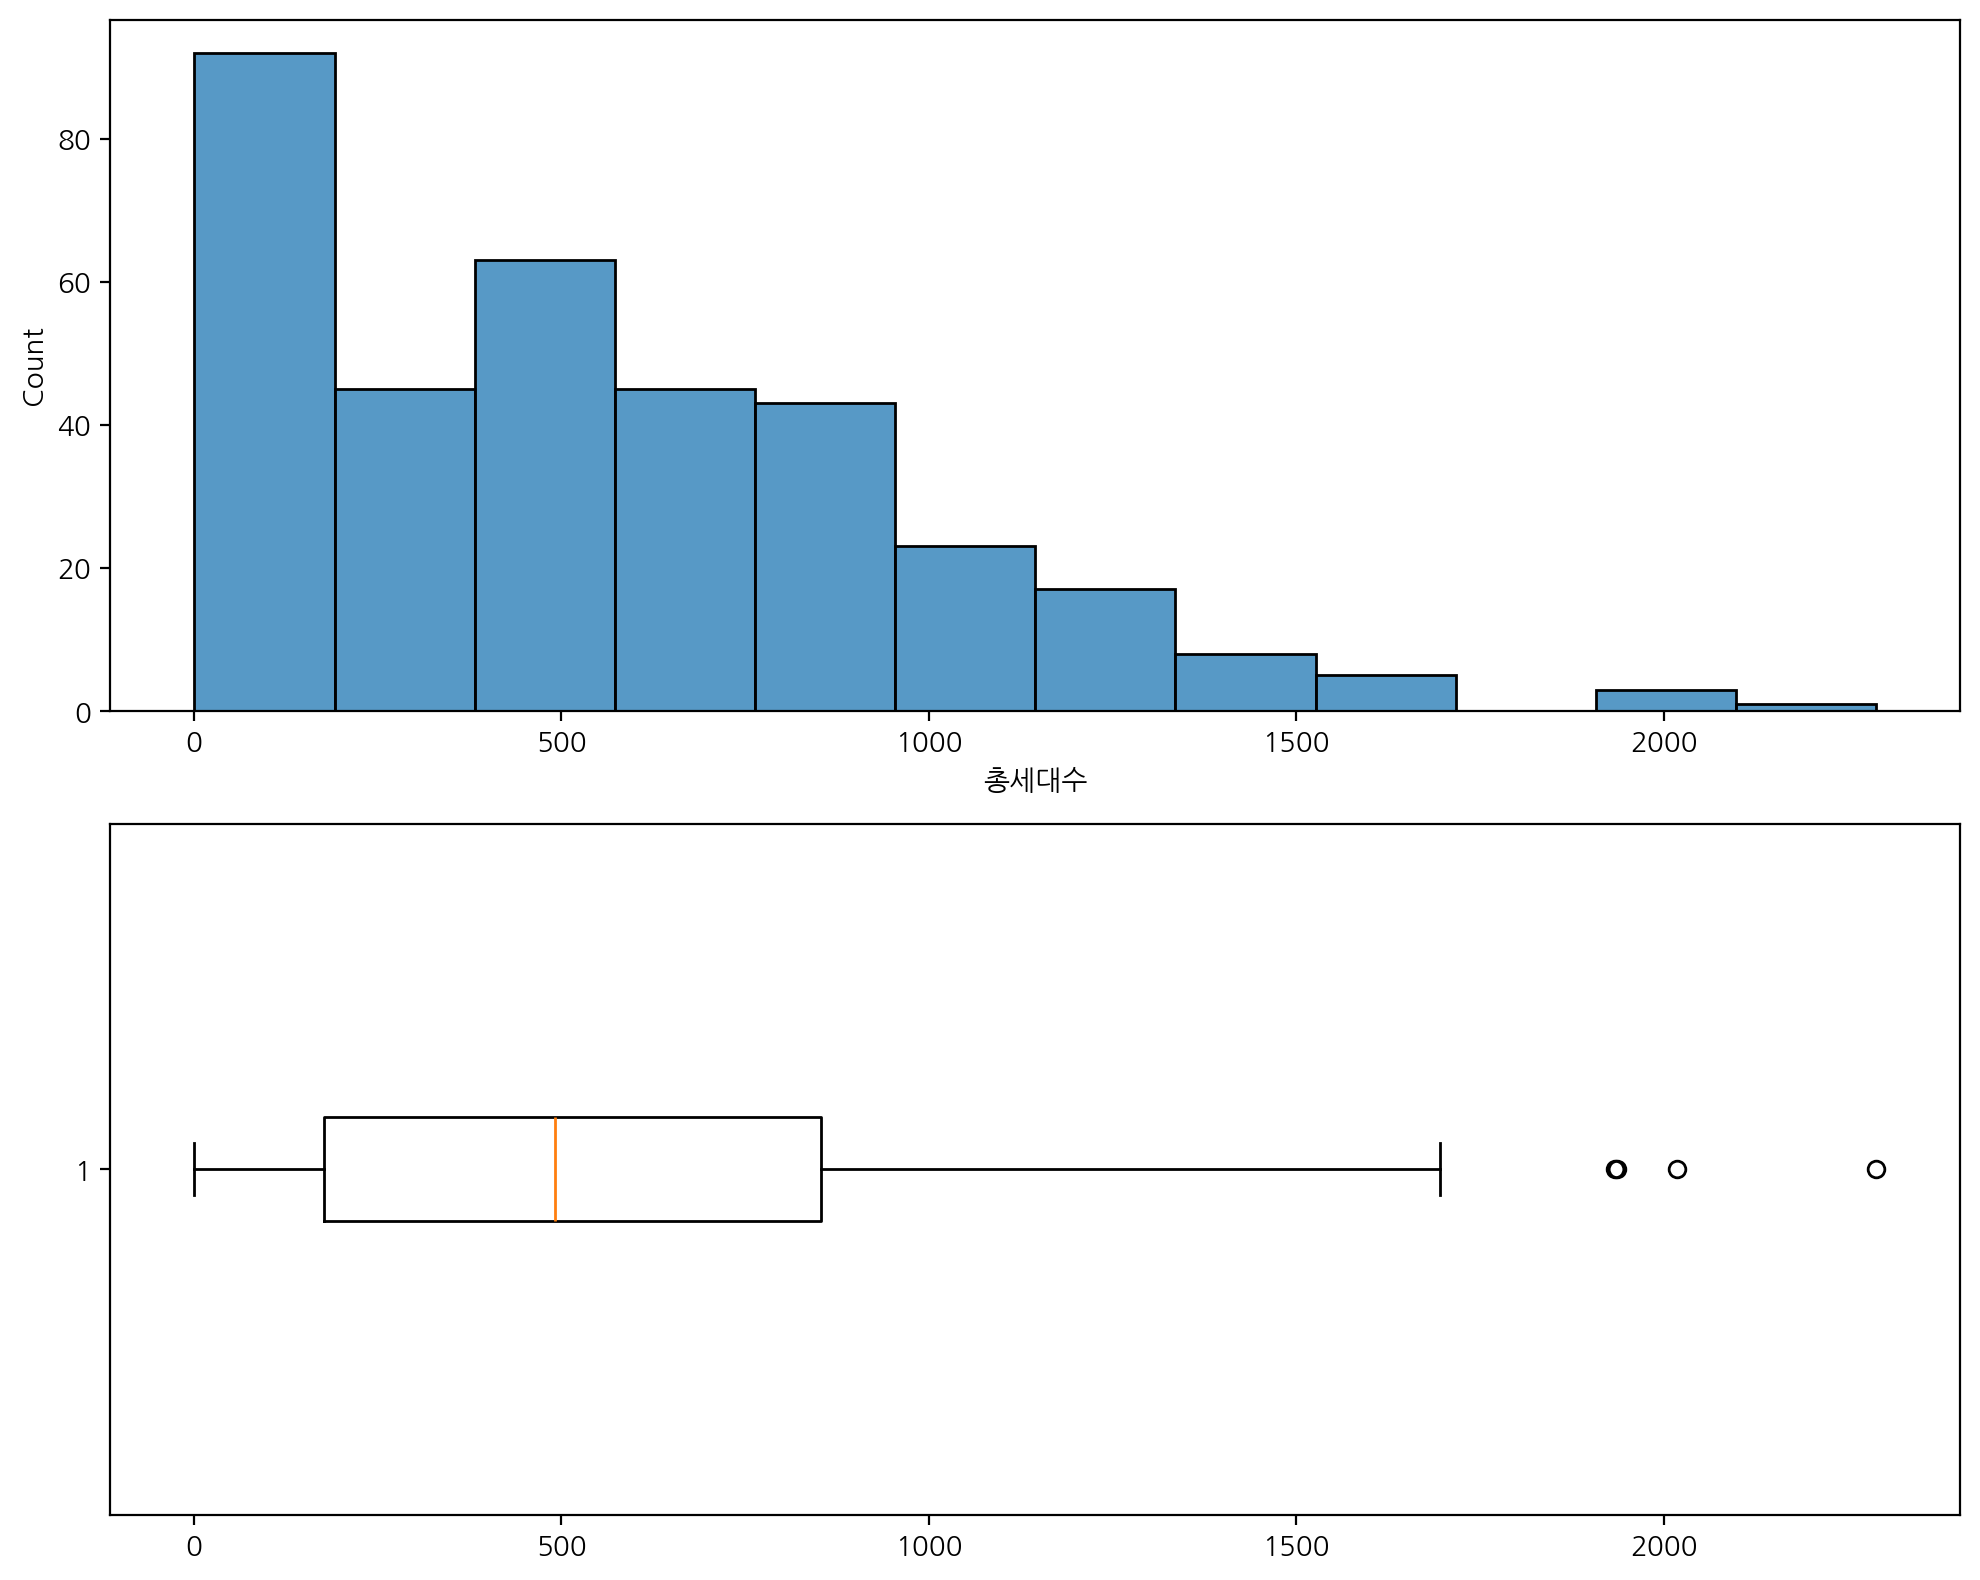

In [318]:
cont_uni('총세대수')

#### 3) 총면적

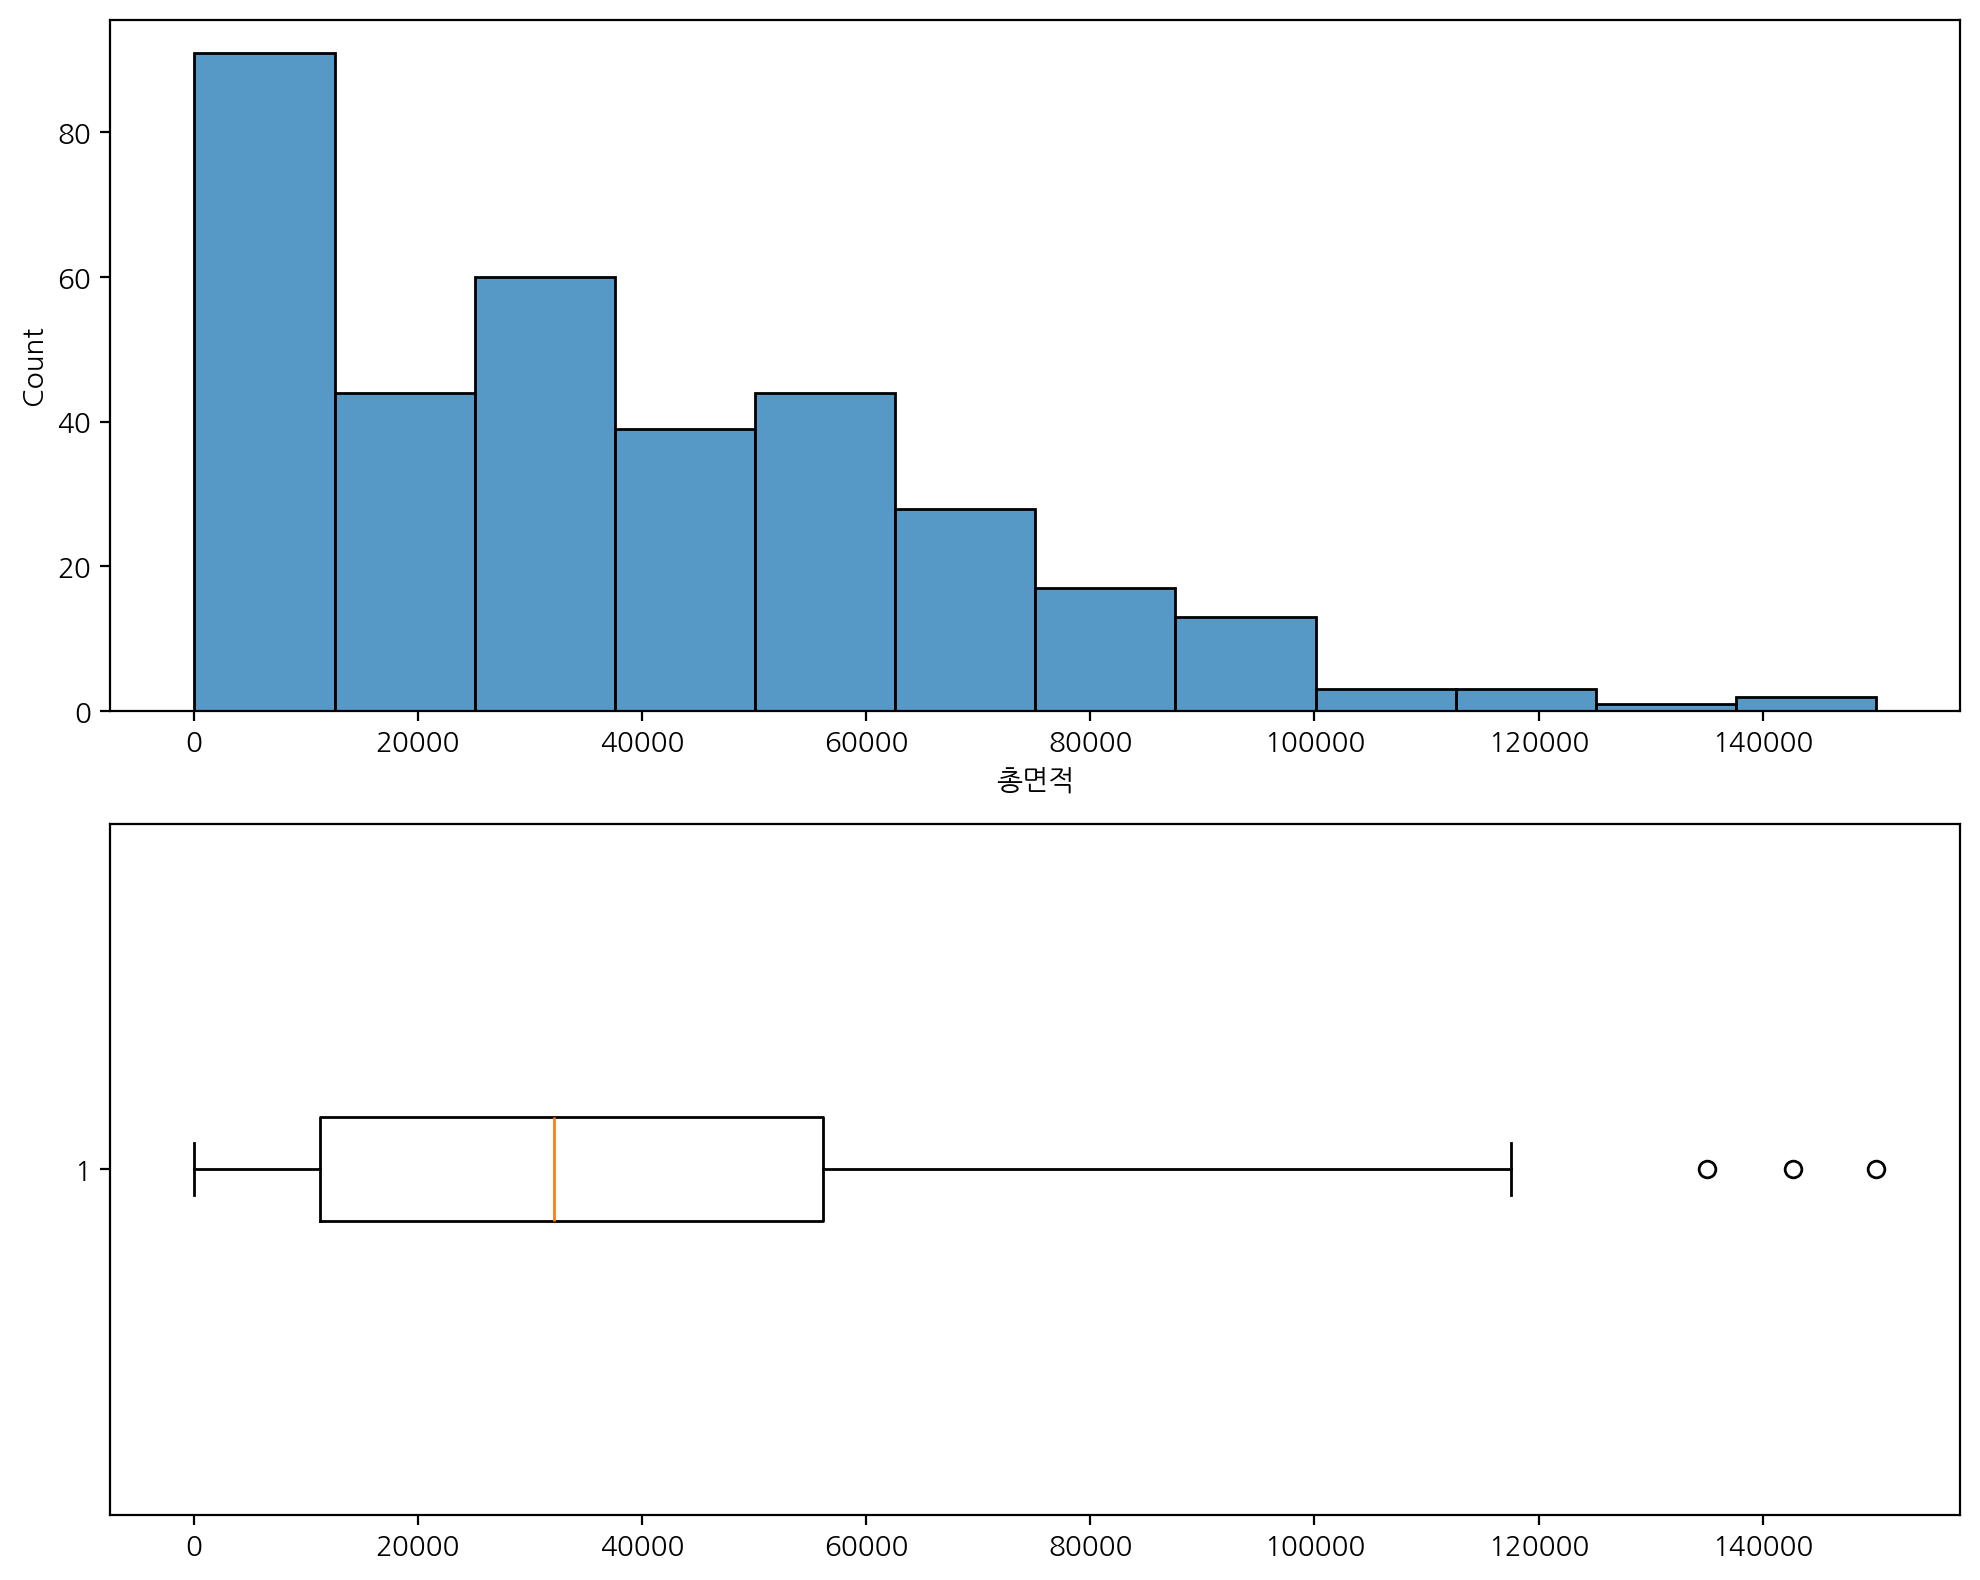

In [320]:
cont_uni('총면적')

#### 4) 준공연도

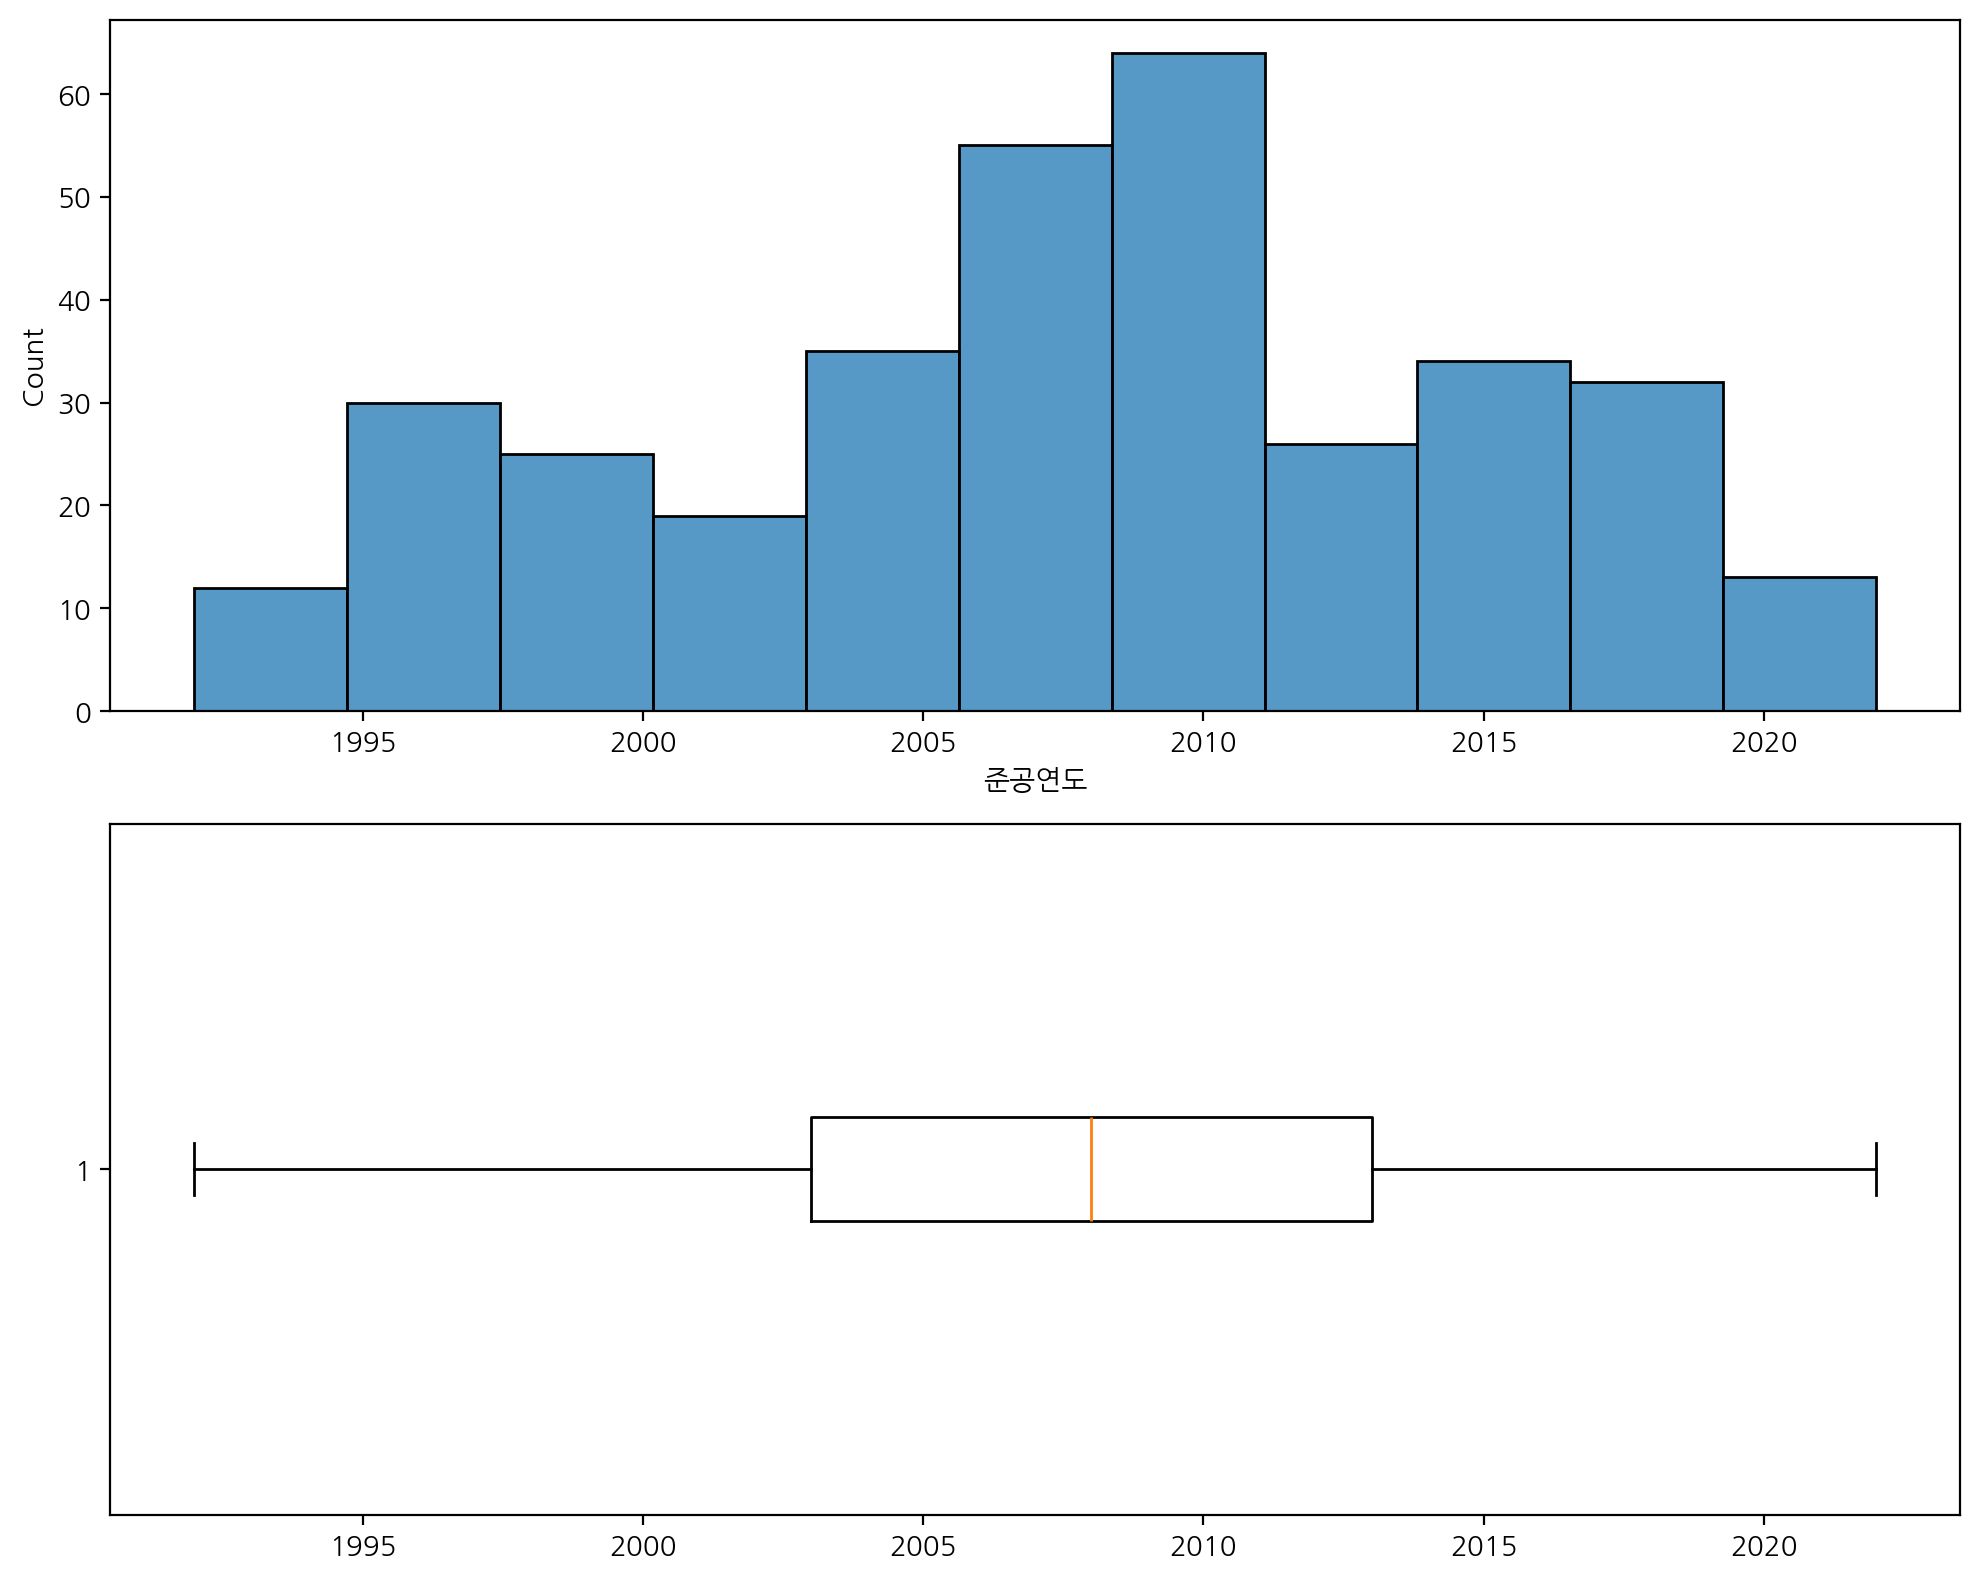

In [322]:
cont_uni('준공연도')

#### 5) 임대료

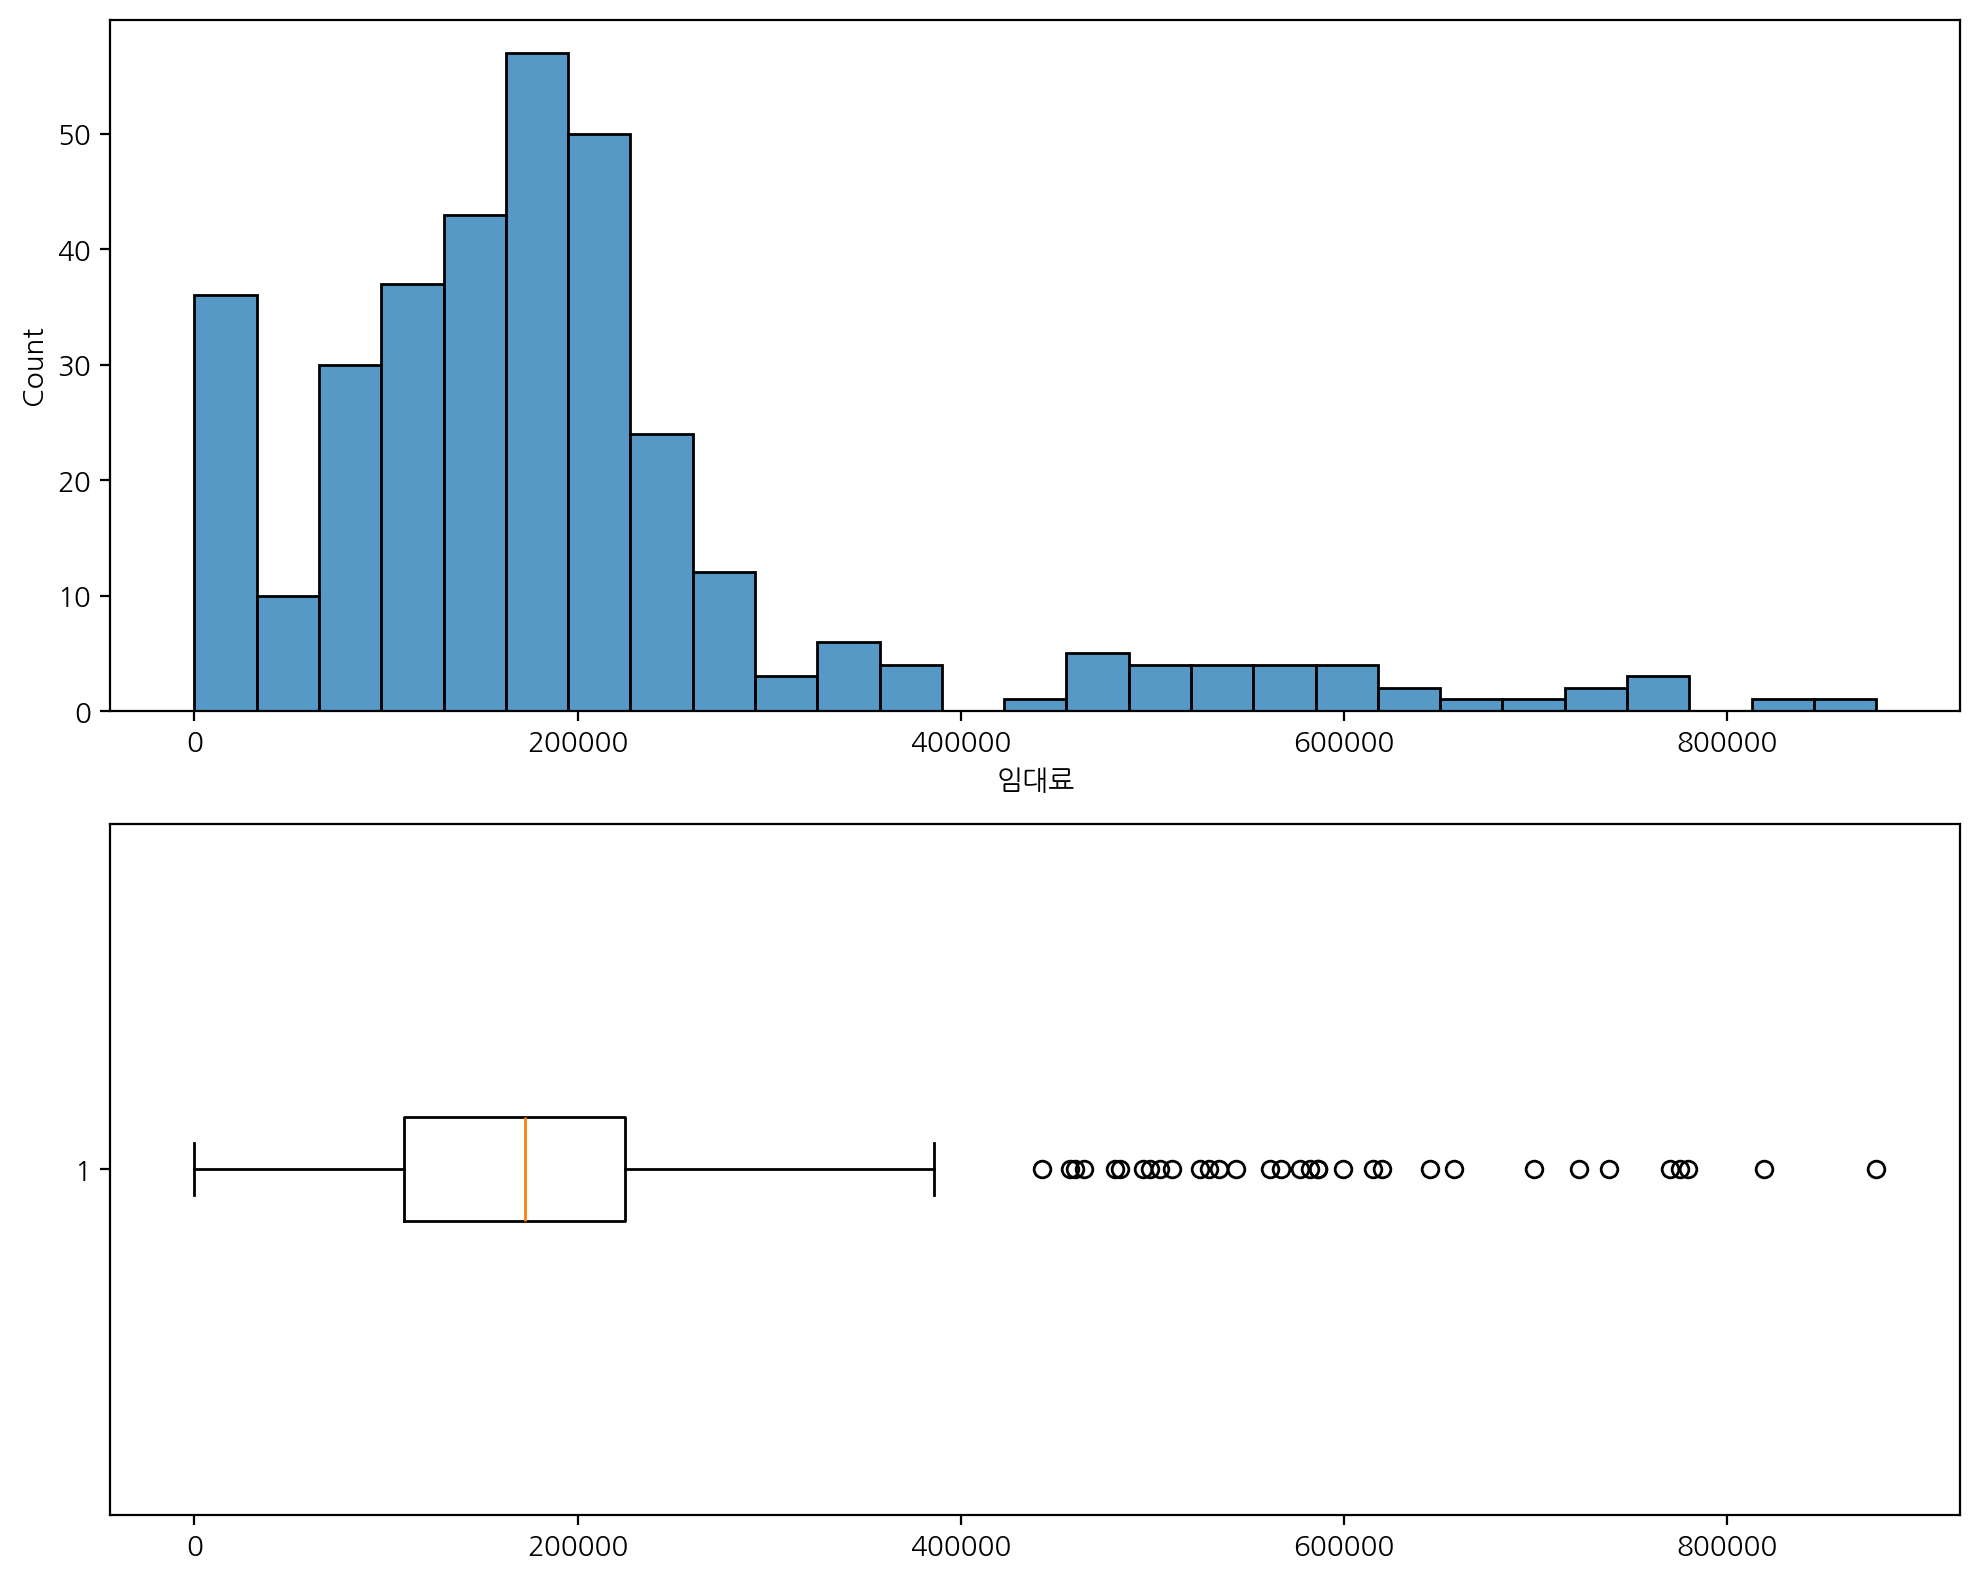

In [324]:
cont_uni('임대료')

#### 6) 임대보증금

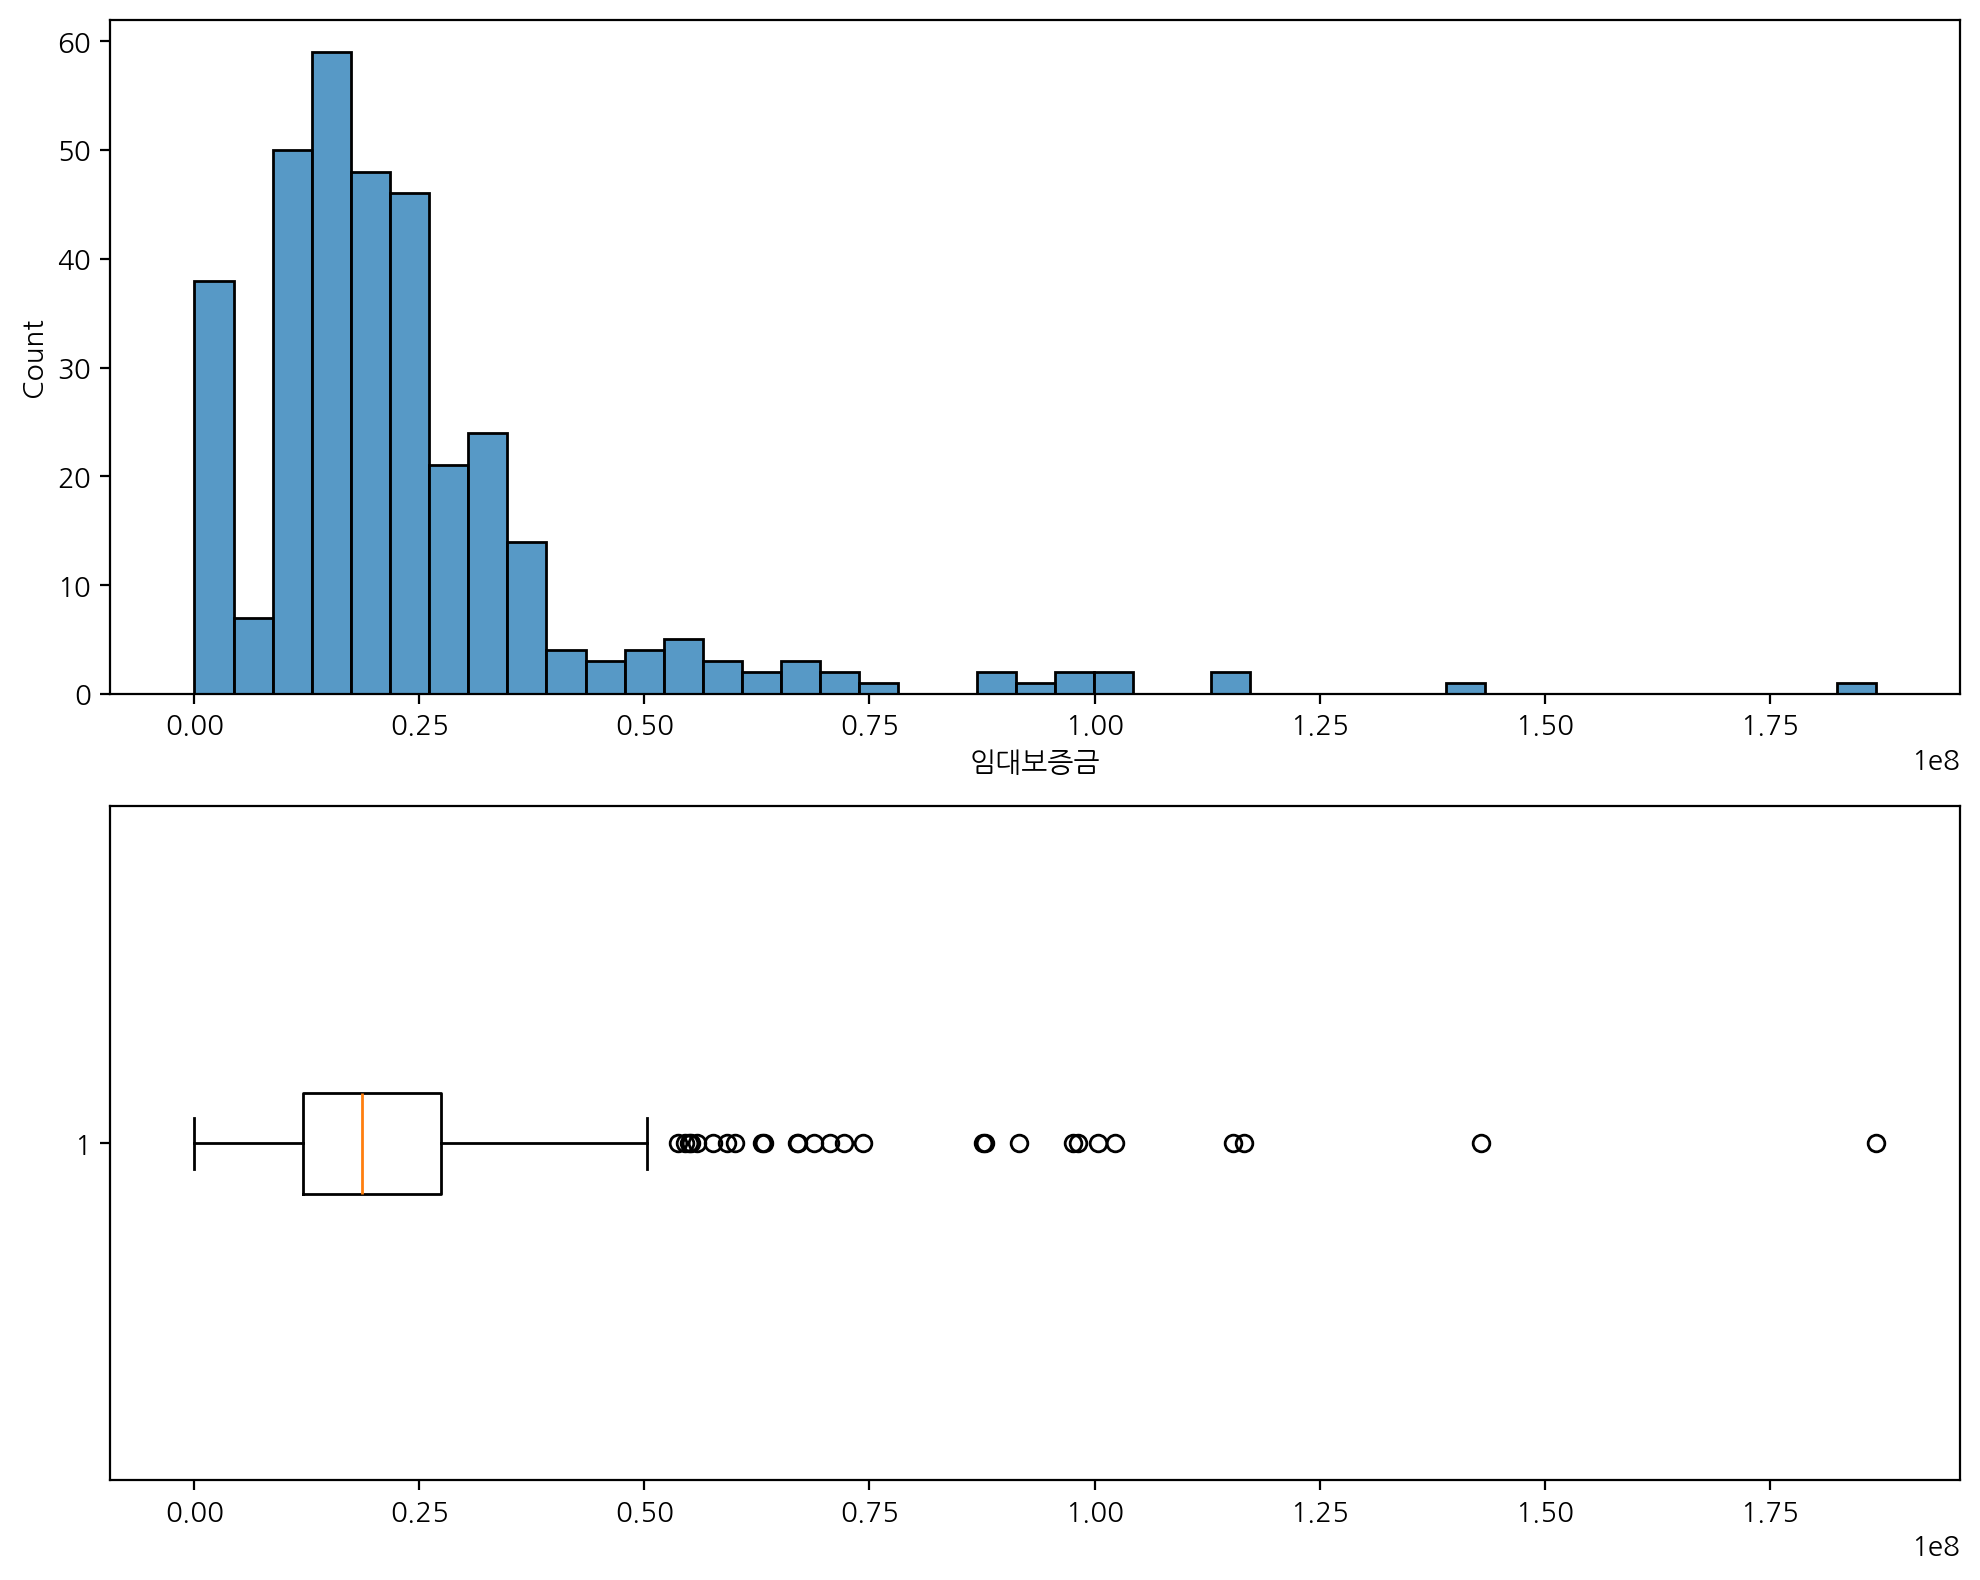

In [326]:
cont_uni('임대보증금')

### (2) 범주형 변수

- 대상: '지역', '건물형태', '난방방식', '승강기설치여부'
- sns.countplot() 함수 등을 사용해 데이터 분포를 확인합니다.
- 반복되는 코드는 함수를 만들어 사용하면 편리합니다.

In [328]:
# 함수 만들기
def cate_uni(col_name):
    plt.figure(figsize=(10,5))
    sns.countplot(x=col_name, data=apart)
    plt.show()

#### 1) 지역

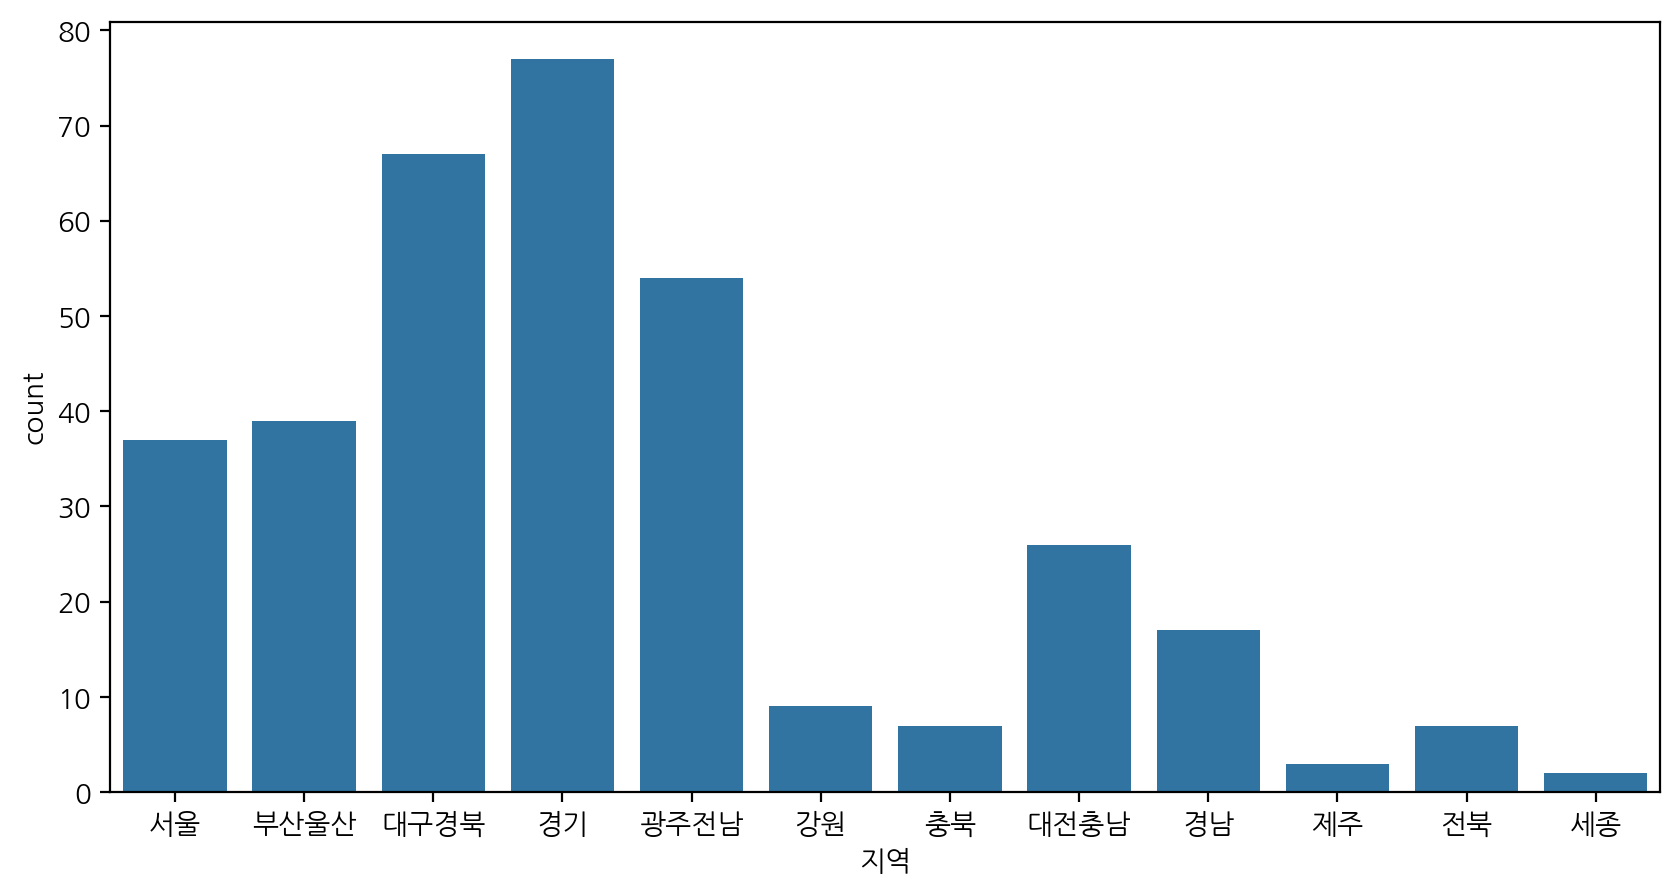

In [330]:
cate_uni('지역')

#### 2) 건물형태

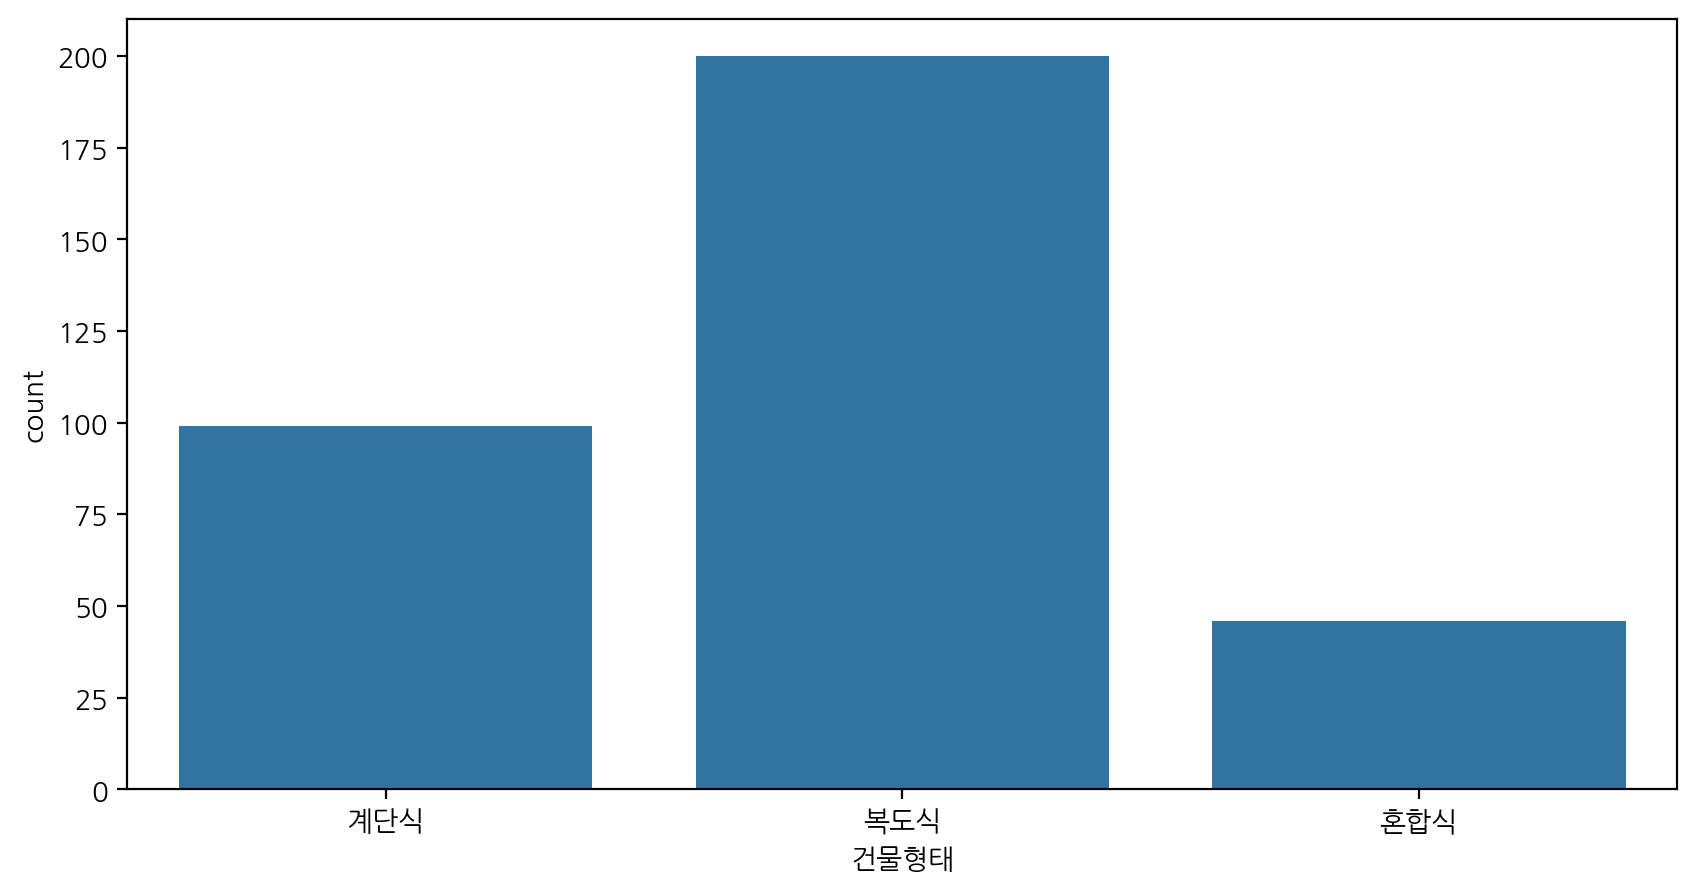

In [332]:
cate_uni('건물형태')

#### 3) 난방방식

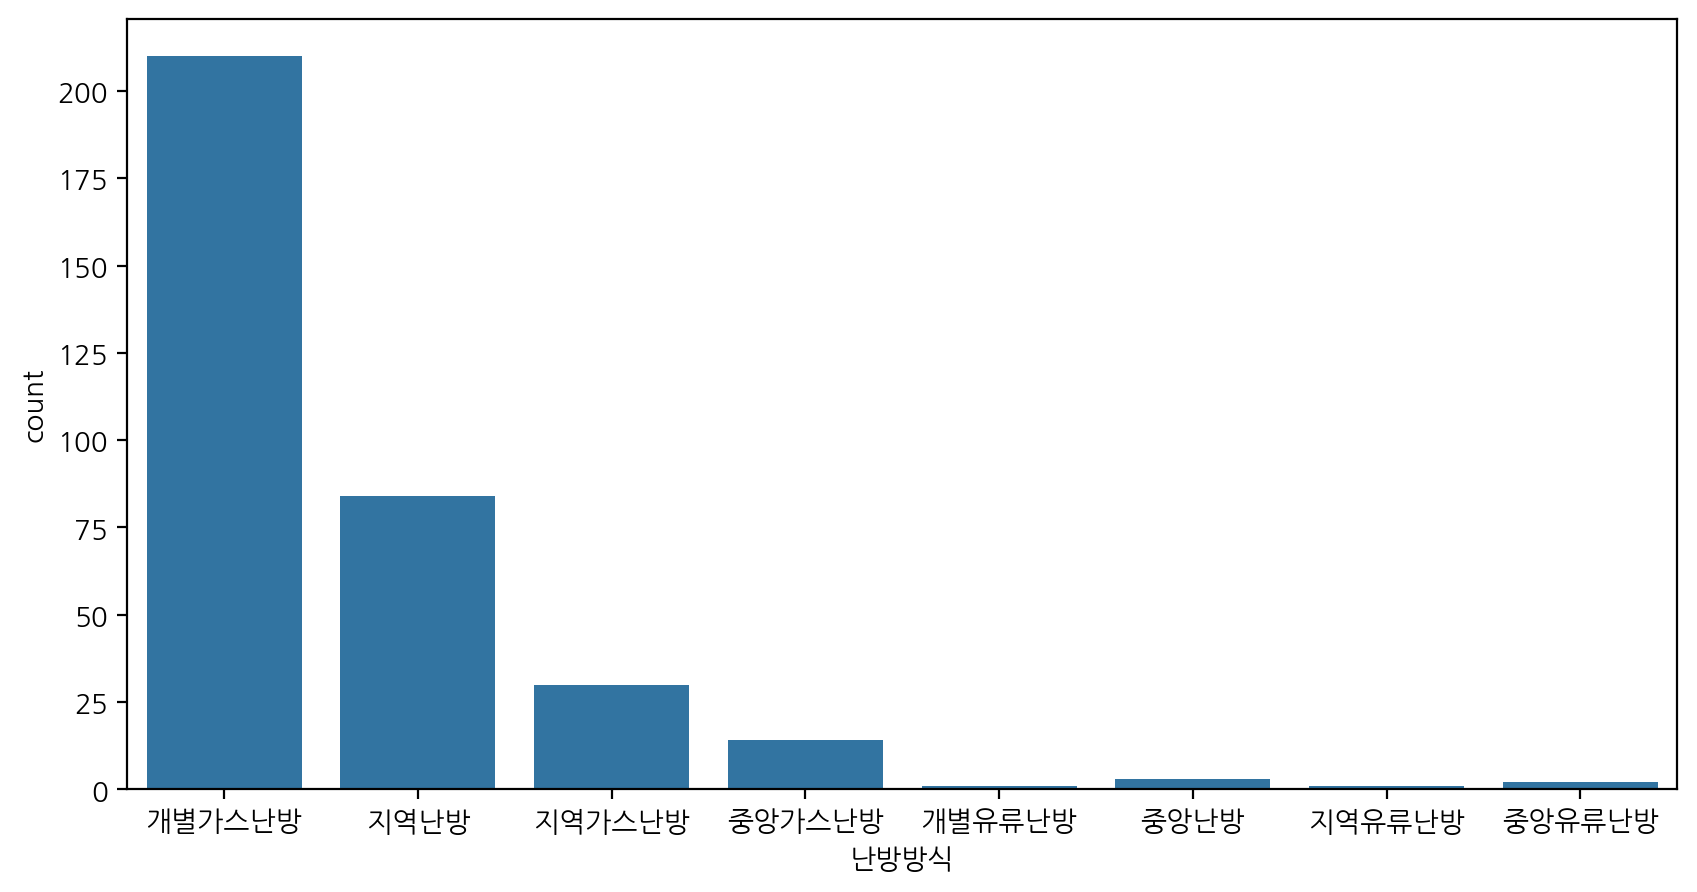

In [334]:
cate_uni('난방방식')

#### 4) 승강기설치여부

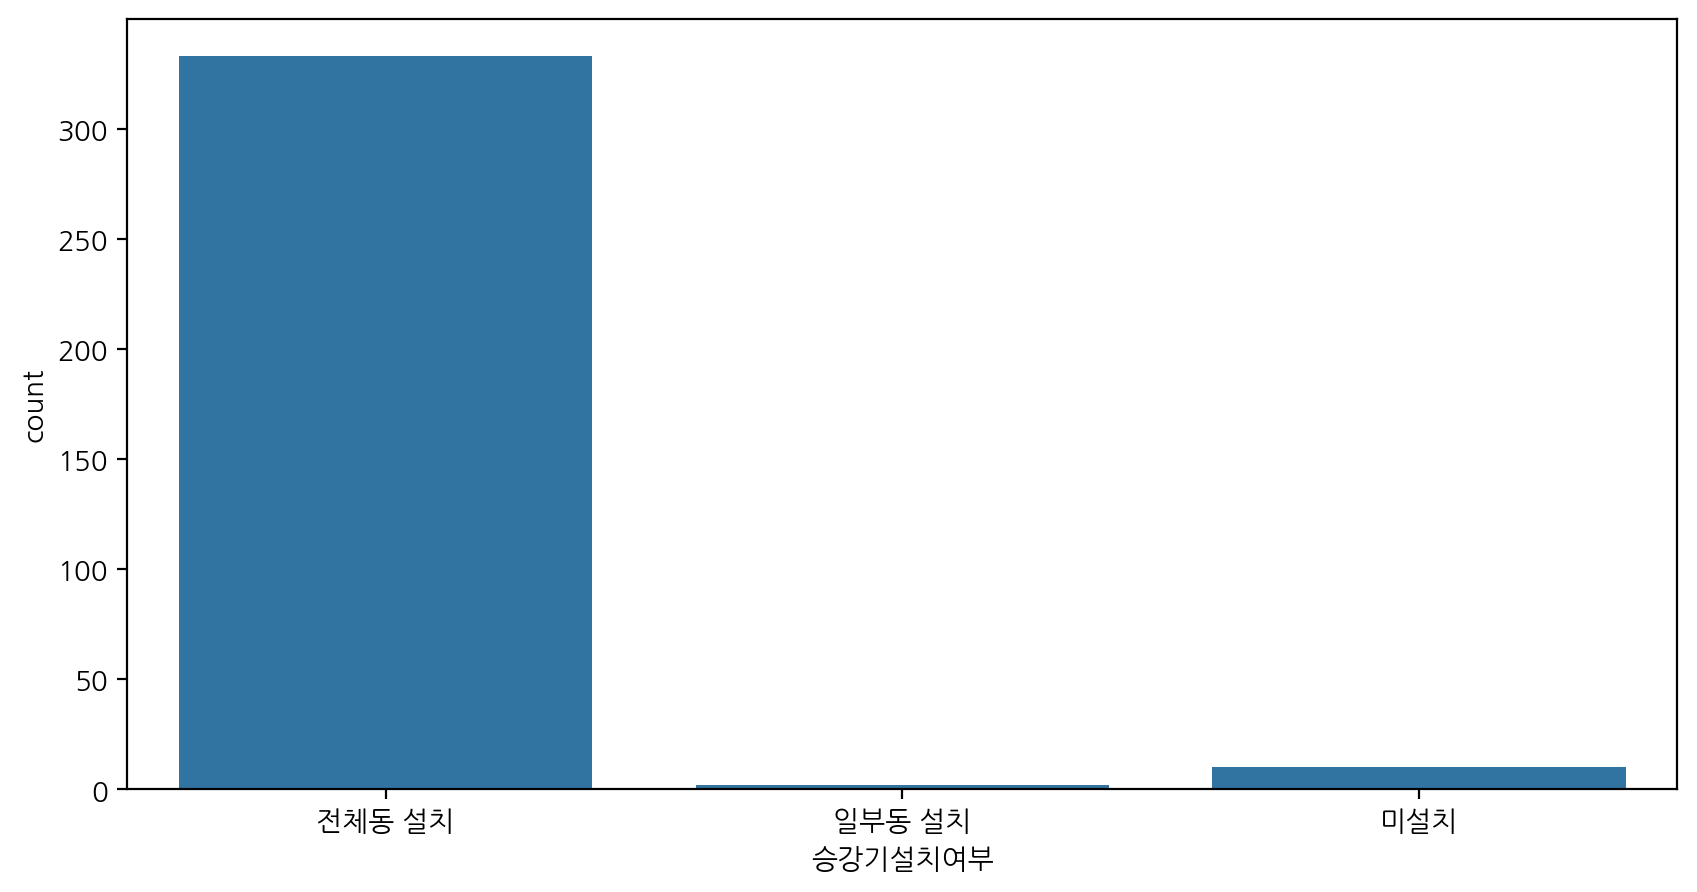

In [336]:
cate_uni('승강기설치여부')

#### 5) 전용면적구간

- 전용면적구간은 pd.melt() 함수를 사용해 pivot을 해제하여 전용면적구간별 세대수를 분석합니다.

In [338]:
melted_apart = pd.melt(
                        apart,
                        id_vars=['단지코드', '총세대수', '지역', '준공연도', '건물형태', '난방방식', '승강기설치여부', '실차량수', '총면적', '임대보증금', '임대료'],
                        value_vars=['면적10_40','면적40_60', '면적60_80', '면적80_200'],
                        var_name='전용면적구간',
                        value_name='세대수'
                    )

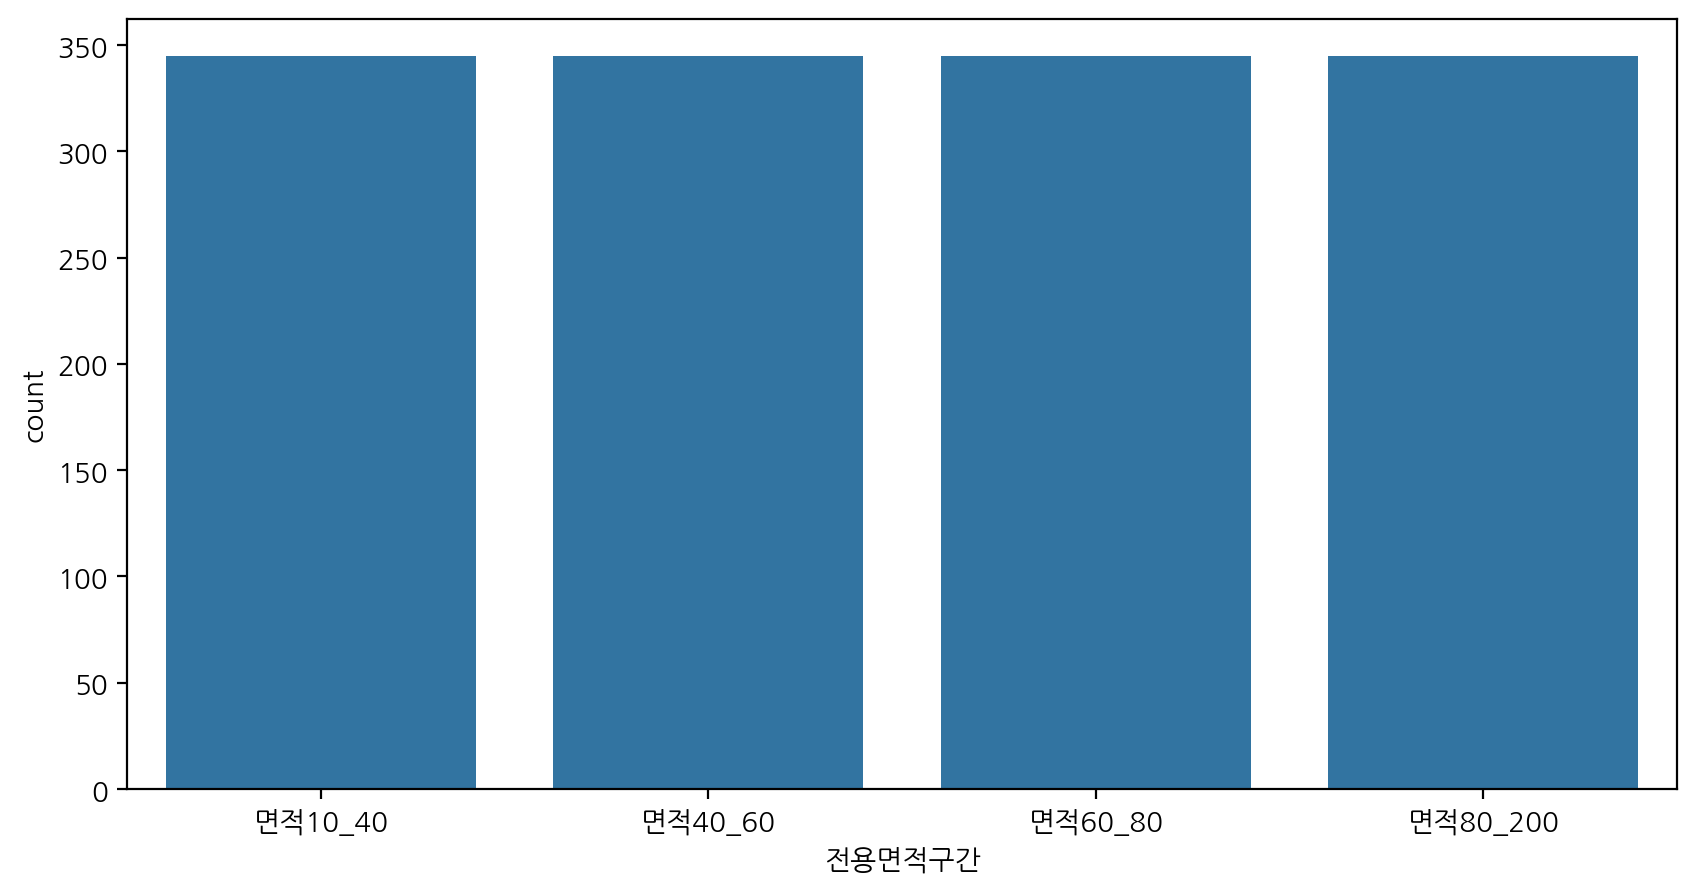

In [339]:
plt.figure(figsize=(10,5))
sns.countplot(x='전용면적구간', data=melted_apart)
plt.show()

## 4. 이변량 분석

- 숫자형 변수들 간의 상관관계를 분석합니다.
- 숫자형 변수 → 실차량수 상관관계를 분석합니다.    
- 볌주형 변수 → 실차량수 관계를 분석합니다.

### (1) 숫자형 변수들 간의 상관관계

- 숫자형 변수 → 실차량수 상관관계를 분석합니다.    
- 숫자형 변수들 간의 상관관계를 df.corr() 메서드와 sns.heatmap() 함수 등을 사용해 시각화 합니다.

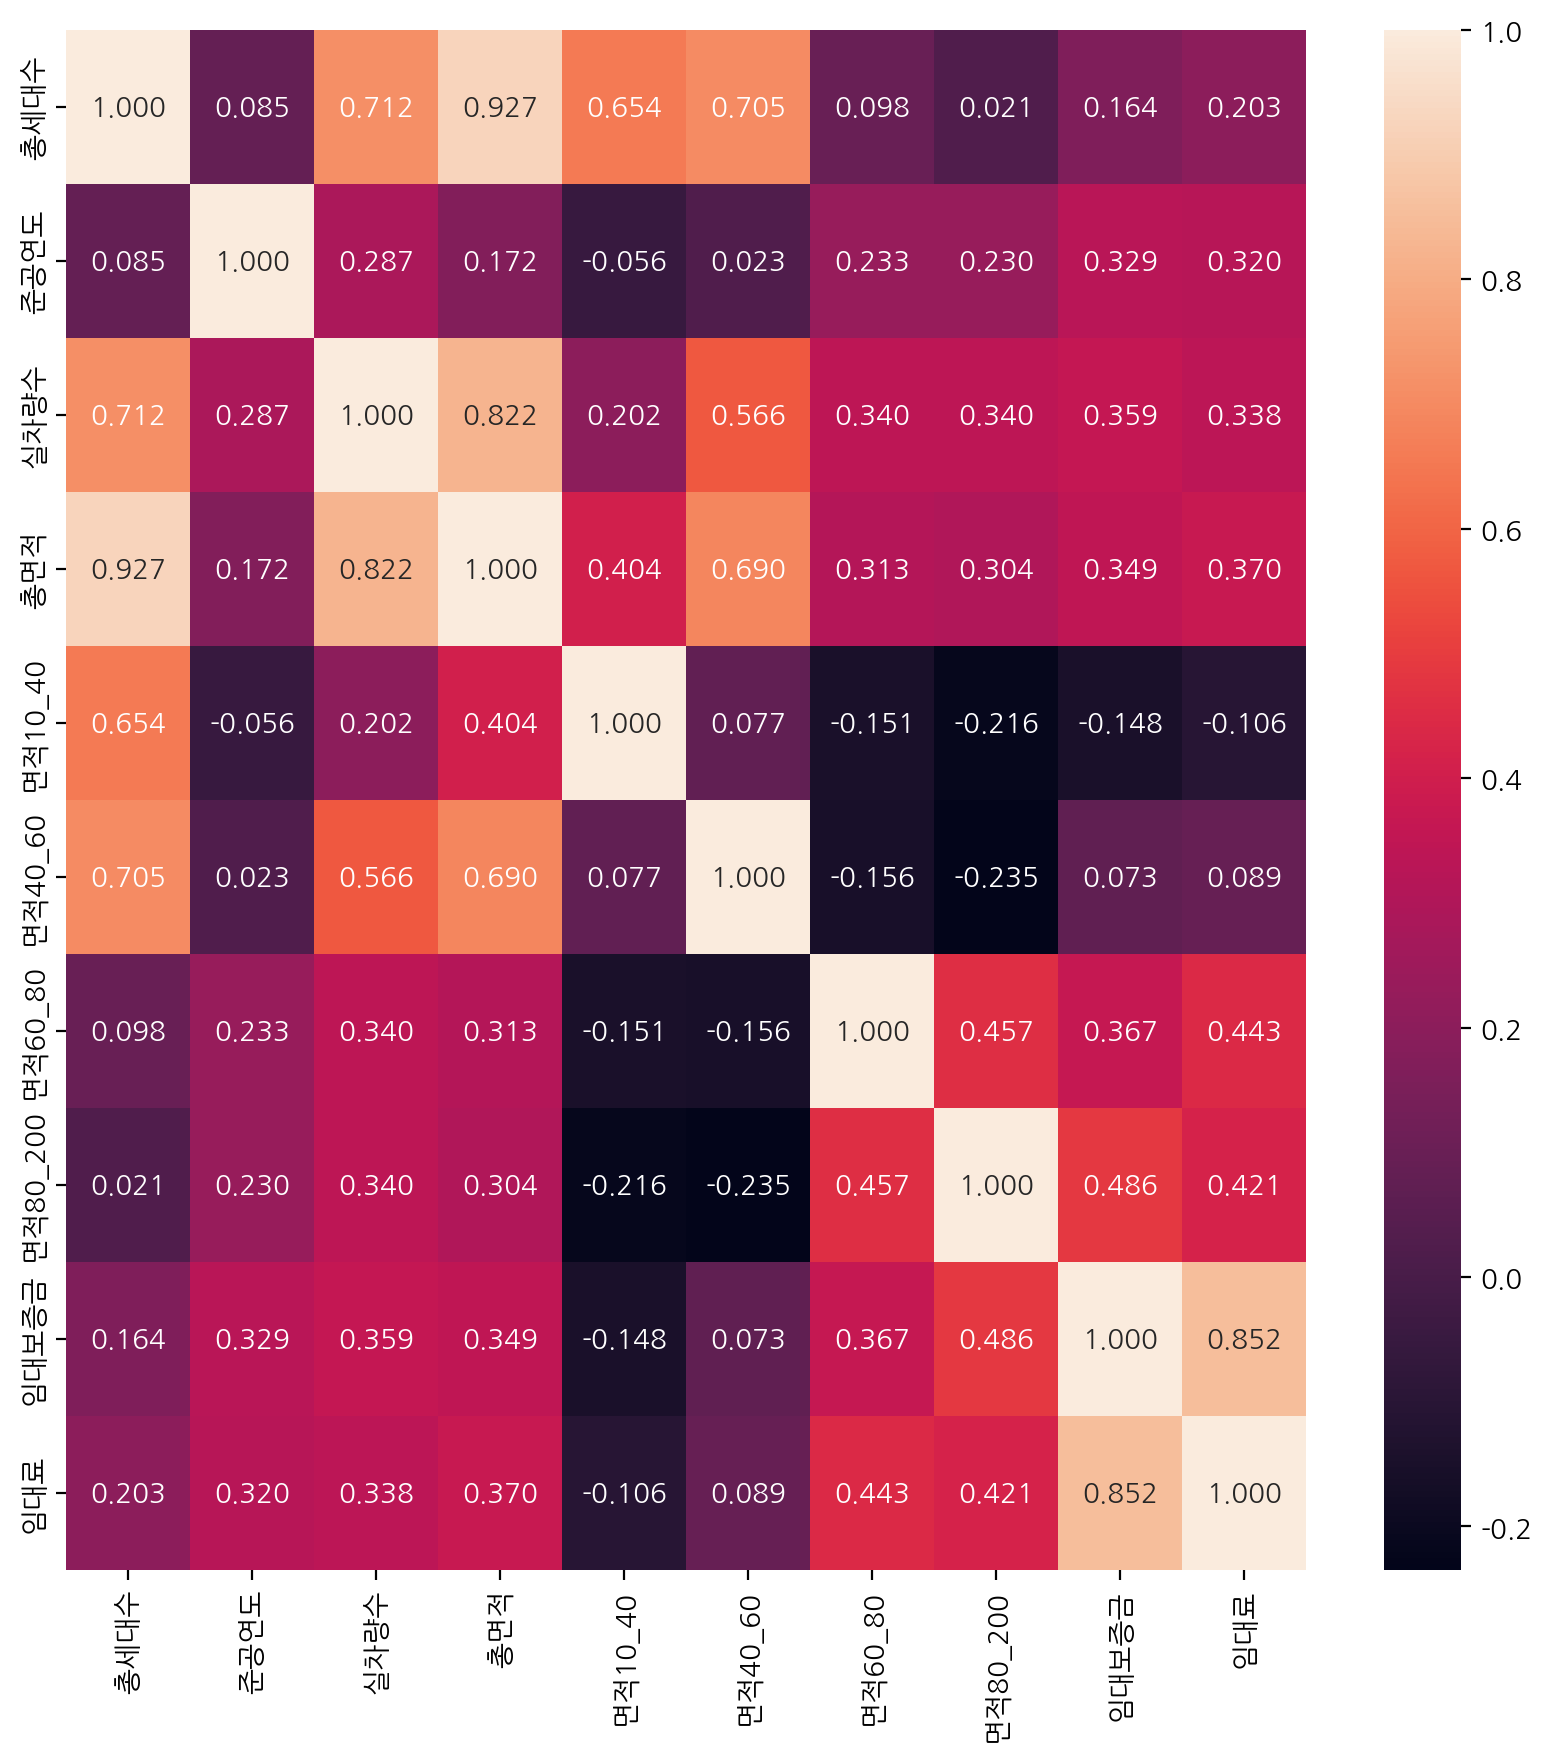

In [342]:
plt.figure(figsize=(10,10))
sns.heatmap(apart.corr(numeric_only=True),
           annot=True,
           fmt='.3f')
plt.show()

### (2) 숫자형 변수 → 실차량수

- 상관계수가 높은 상위 3~5개 숫자형 변수와 실차량수 관계를 산점도를 시각화해 분석합니다.
- 반복되는 코드는 함수를 만들어 사용하면 편리합니다.

In [344]:
# 함수 만들기
def cont_bi(col_name):
    # x가 0이 아닌 데이터로 필터링
    filtered_data = apart[apart[col_name] != 0]
    
    plt.figure(figsize=(8, 5))
    sns.regplot(x=col_name, y='실차량수', data=filtered_data)
    plt.show()
    
    # 필터링된 데이터로 상관계수 계산
    correlation = spst.pearsonr(filtered_data['실차량수'], filtered_data[col_name])
    print(correlation)

#### 1) 총면적

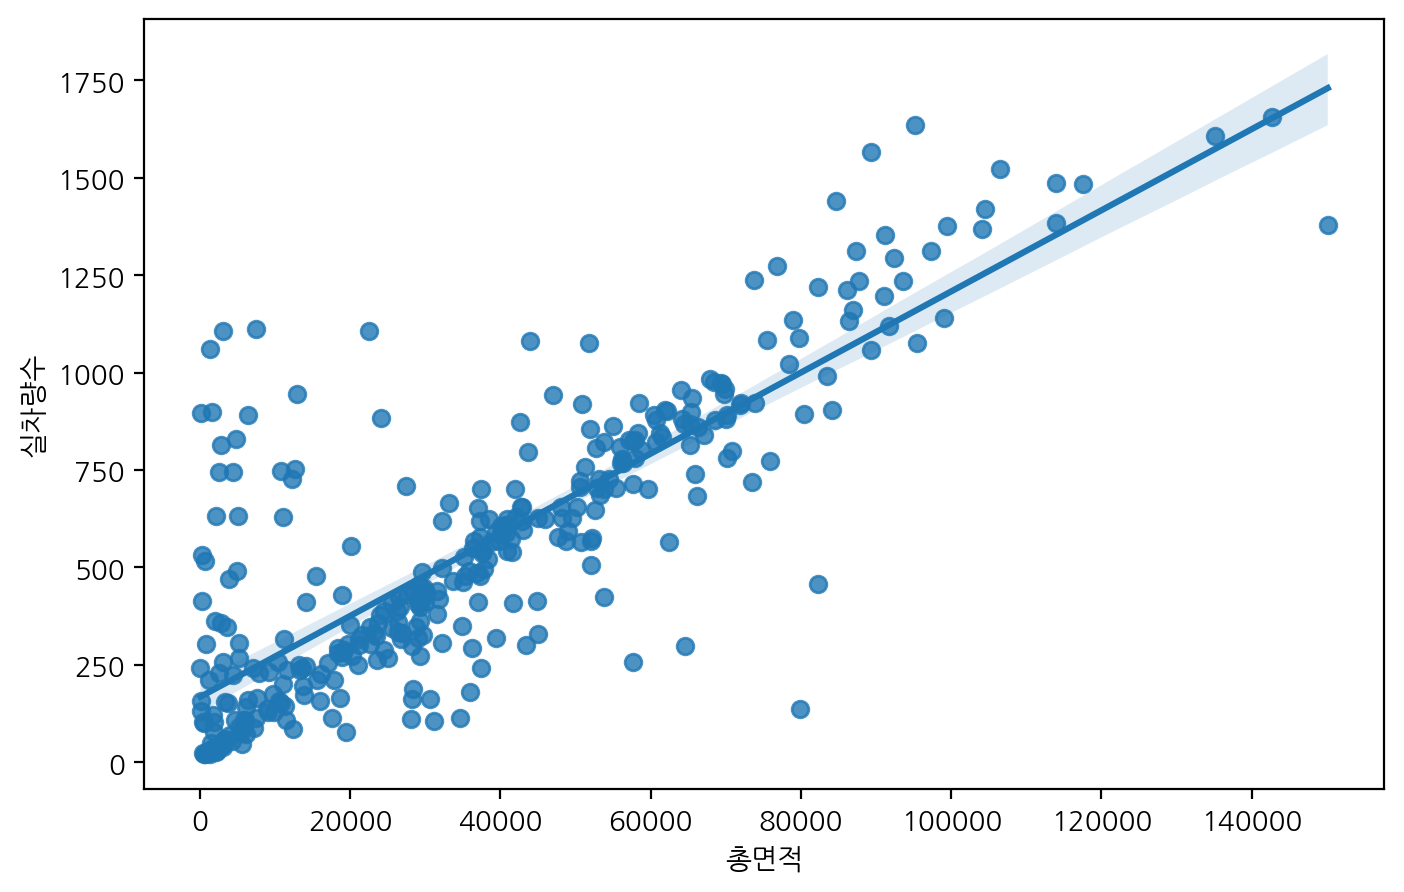

PearsonRResult(statistic=0.8221825549027681, pvalue=6.032798759323943e-86)


In [346]:
cont_bi('총면적')

#### 2) 총세대수

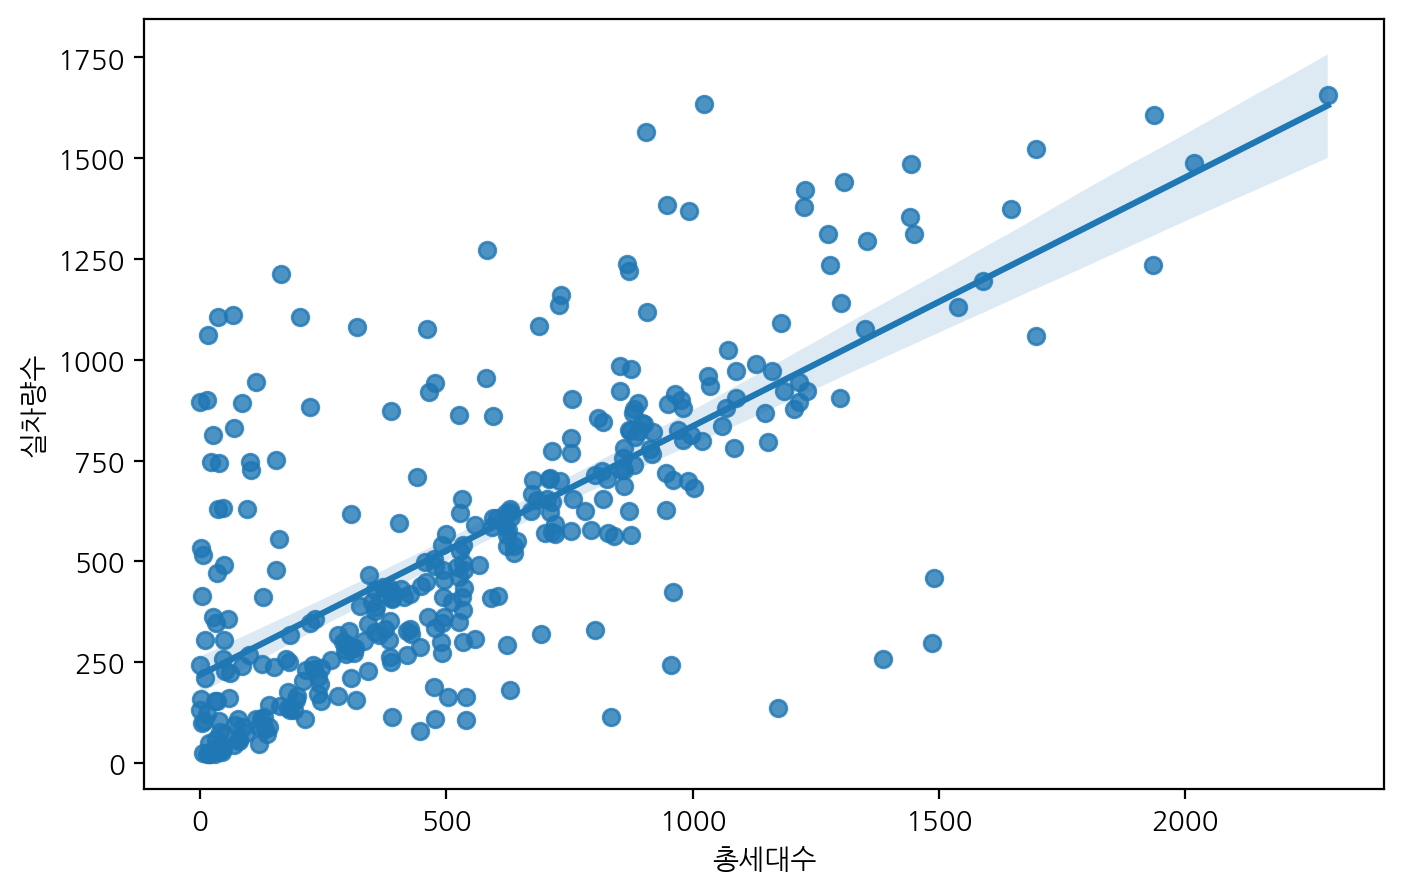

PearsonRResult(statistic=0.7124746462088557, pvalue=1.0221045732952228e-54)


In [348]:
cont_bi('총세대수')

#### 3) 면적40_60

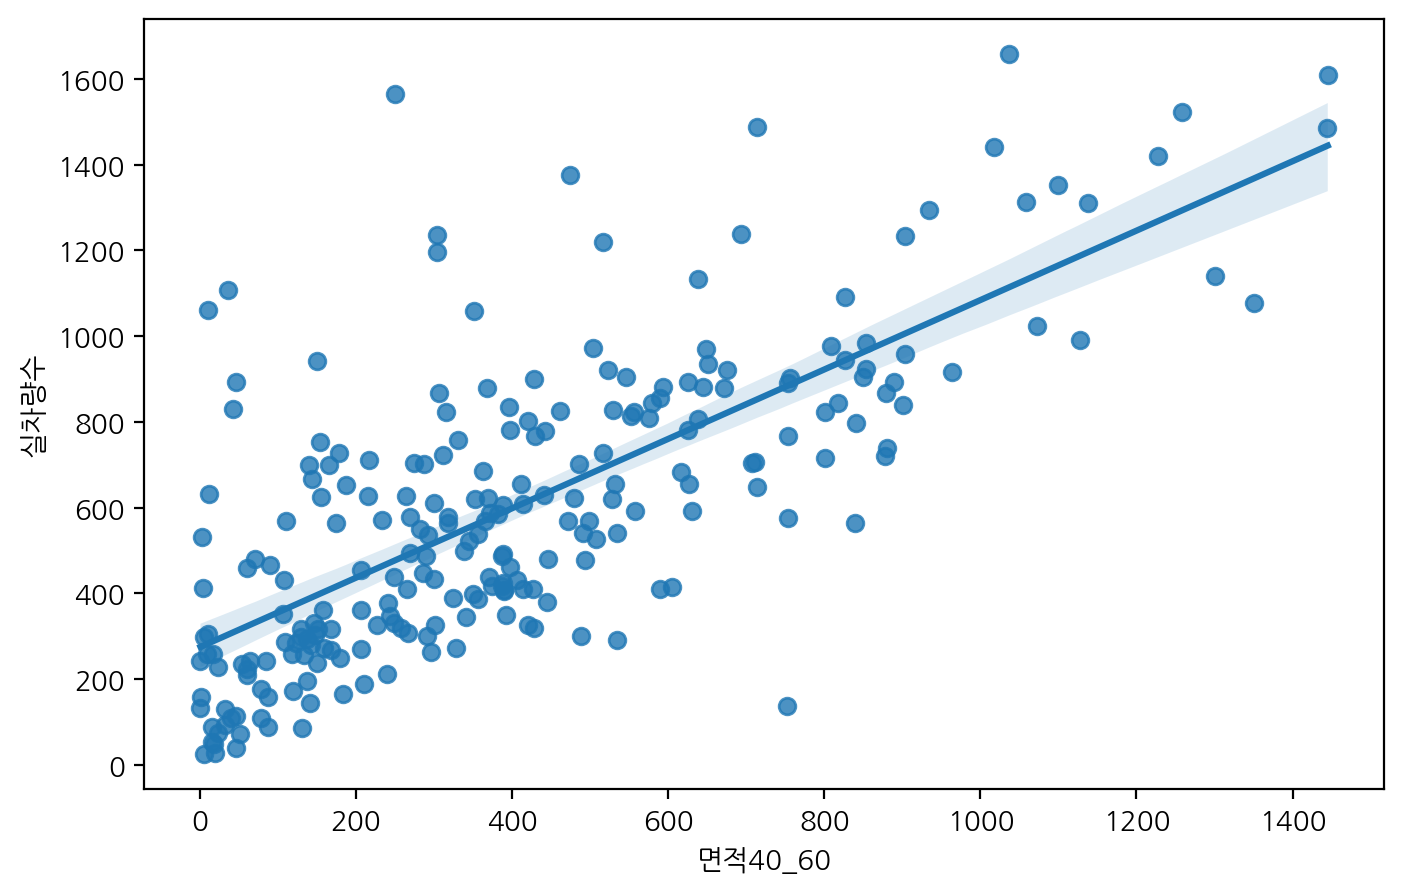

PearsonRResult(statistic=0.7260802209405941, pvalue=2.0026545971376534e-40)


In [350]:
cont_bi('면적40_60')

#### 4) 임대보증금

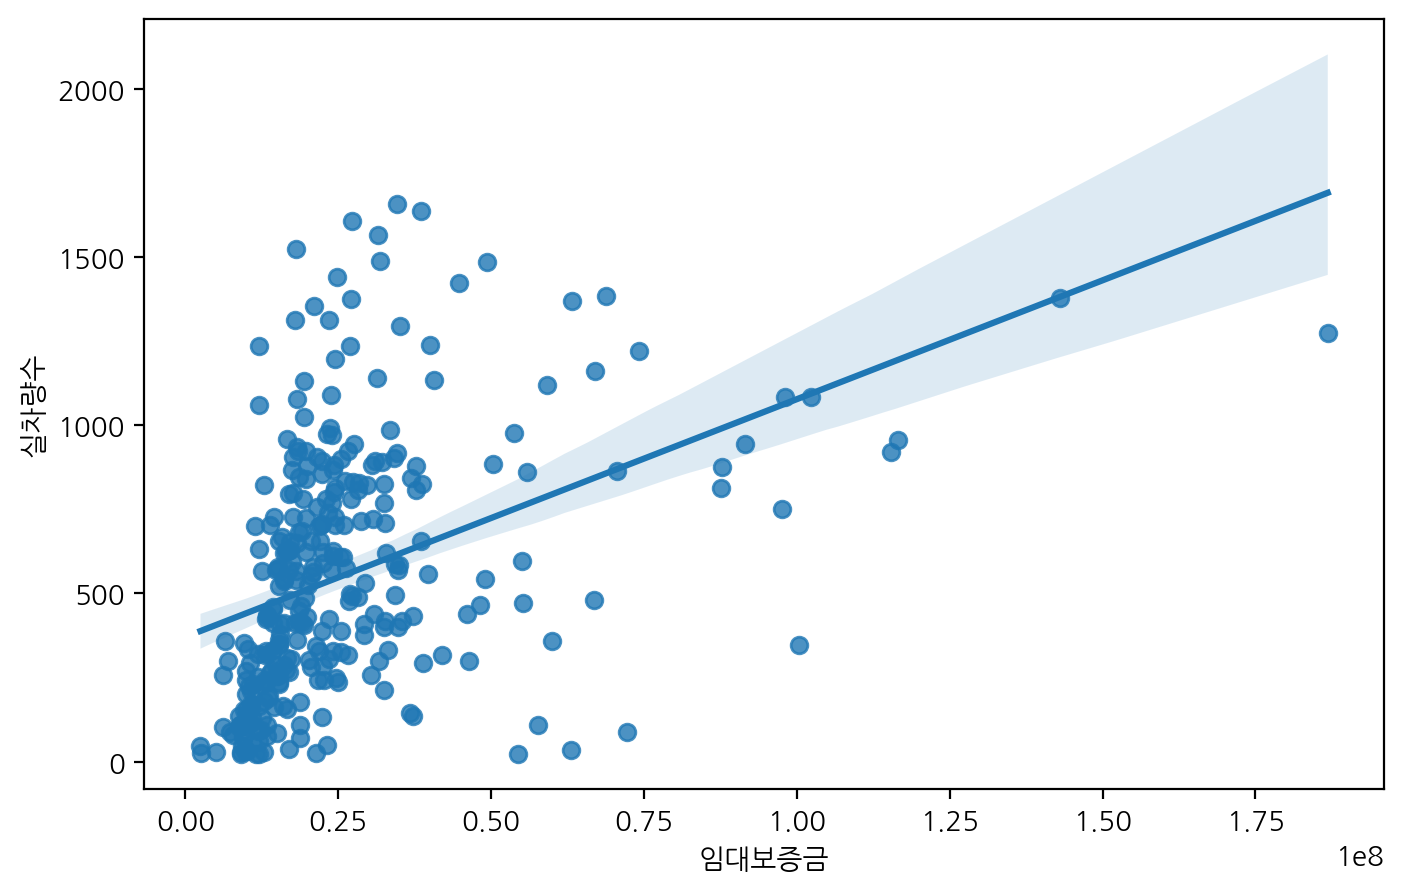

PearsonRResult(statistic=0.4055409167644373, pvalue=1.1609421672771715e-13)


In [352]:
cont_bi('임대보증금')

#### 5) 임대료

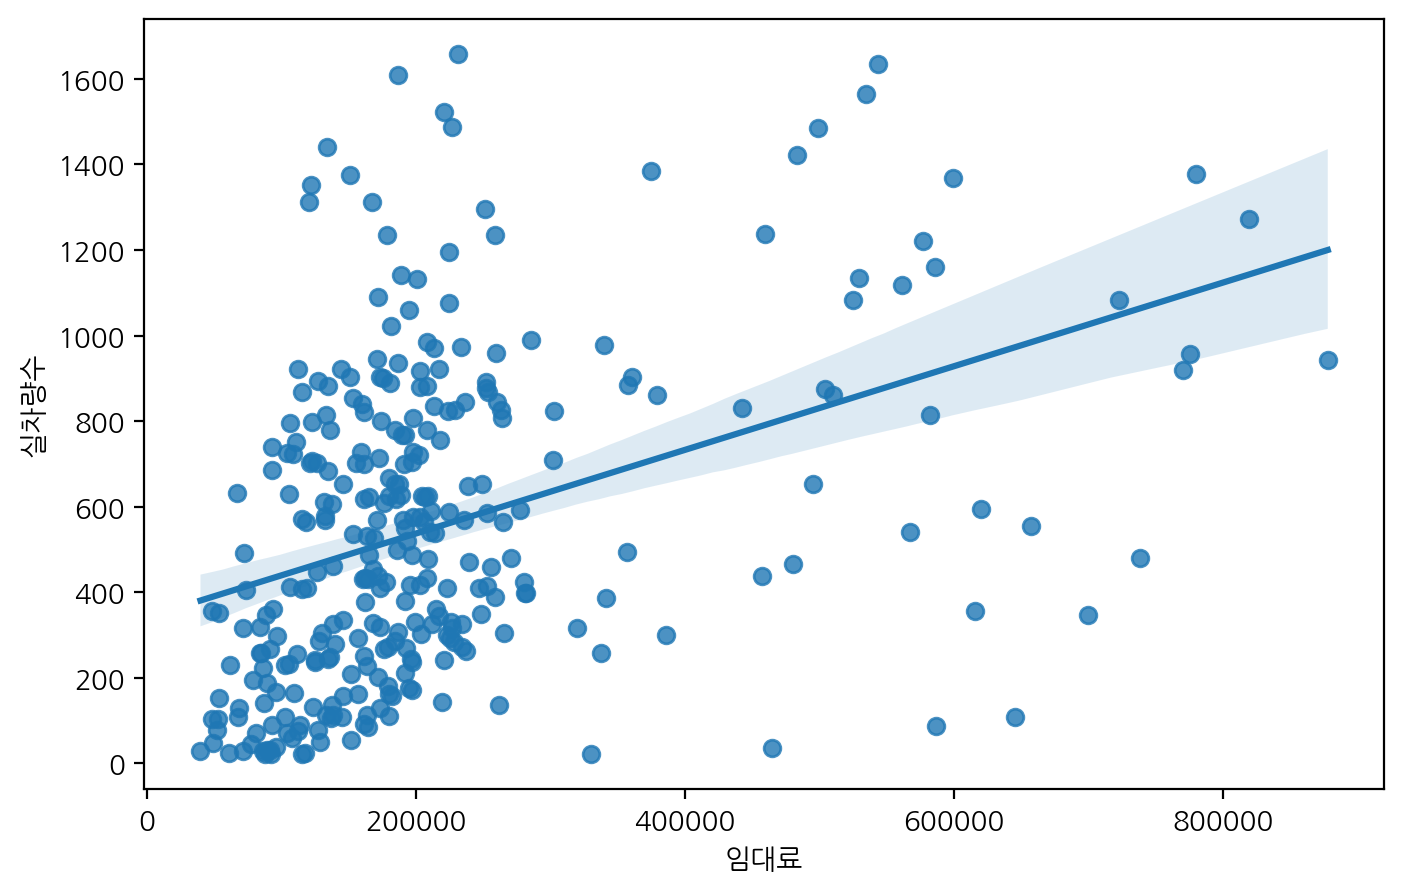

PearsonRResult(statistic=0.39194428424638206, pvalue=8.682158018813766e-13)


In [354]:
cont_bi('임대료')

### (3) 범주형 변수 → 실차량수

- 범주형 변수 → 실차량수 관계를 분석합니다.
- 대상: '지역', '준공연도', '건물형태', '난방방식', '승강기설치여부'
- 범줏값 별 실차량수 평균을 막대그래프로 시각화해 분석합니다.
- 반복되는 코드는 함수를 만들어 사용하면 편리합니다.

In [357]:
# 함수 만들기
def cate_bi(col_name):
    plt.figure(figsize=(10,6))
    sns.barplot(x=col_name, y='실차량수', data=apart)
    plt.xticks(rotation=90)
    plt.show()

#### 1) 지역

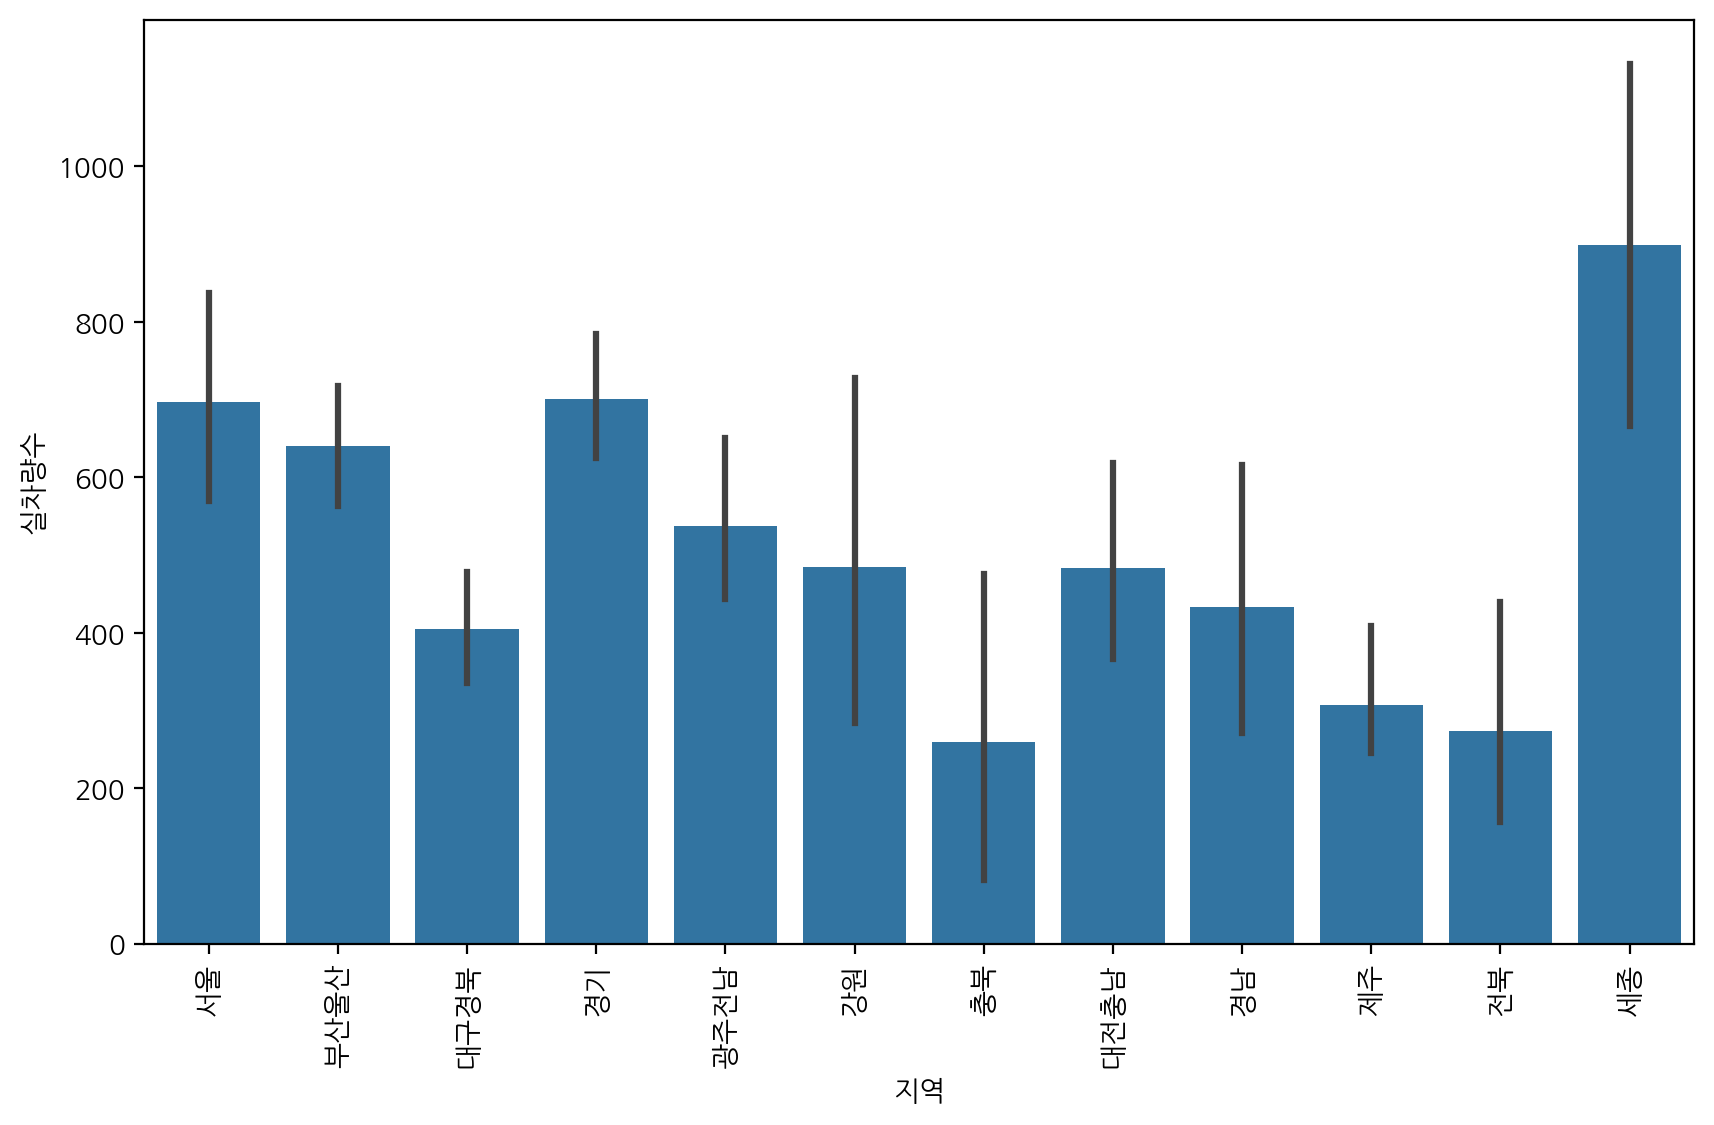

In [359]:
cate_bi('지역')

#### 2) 준공연도

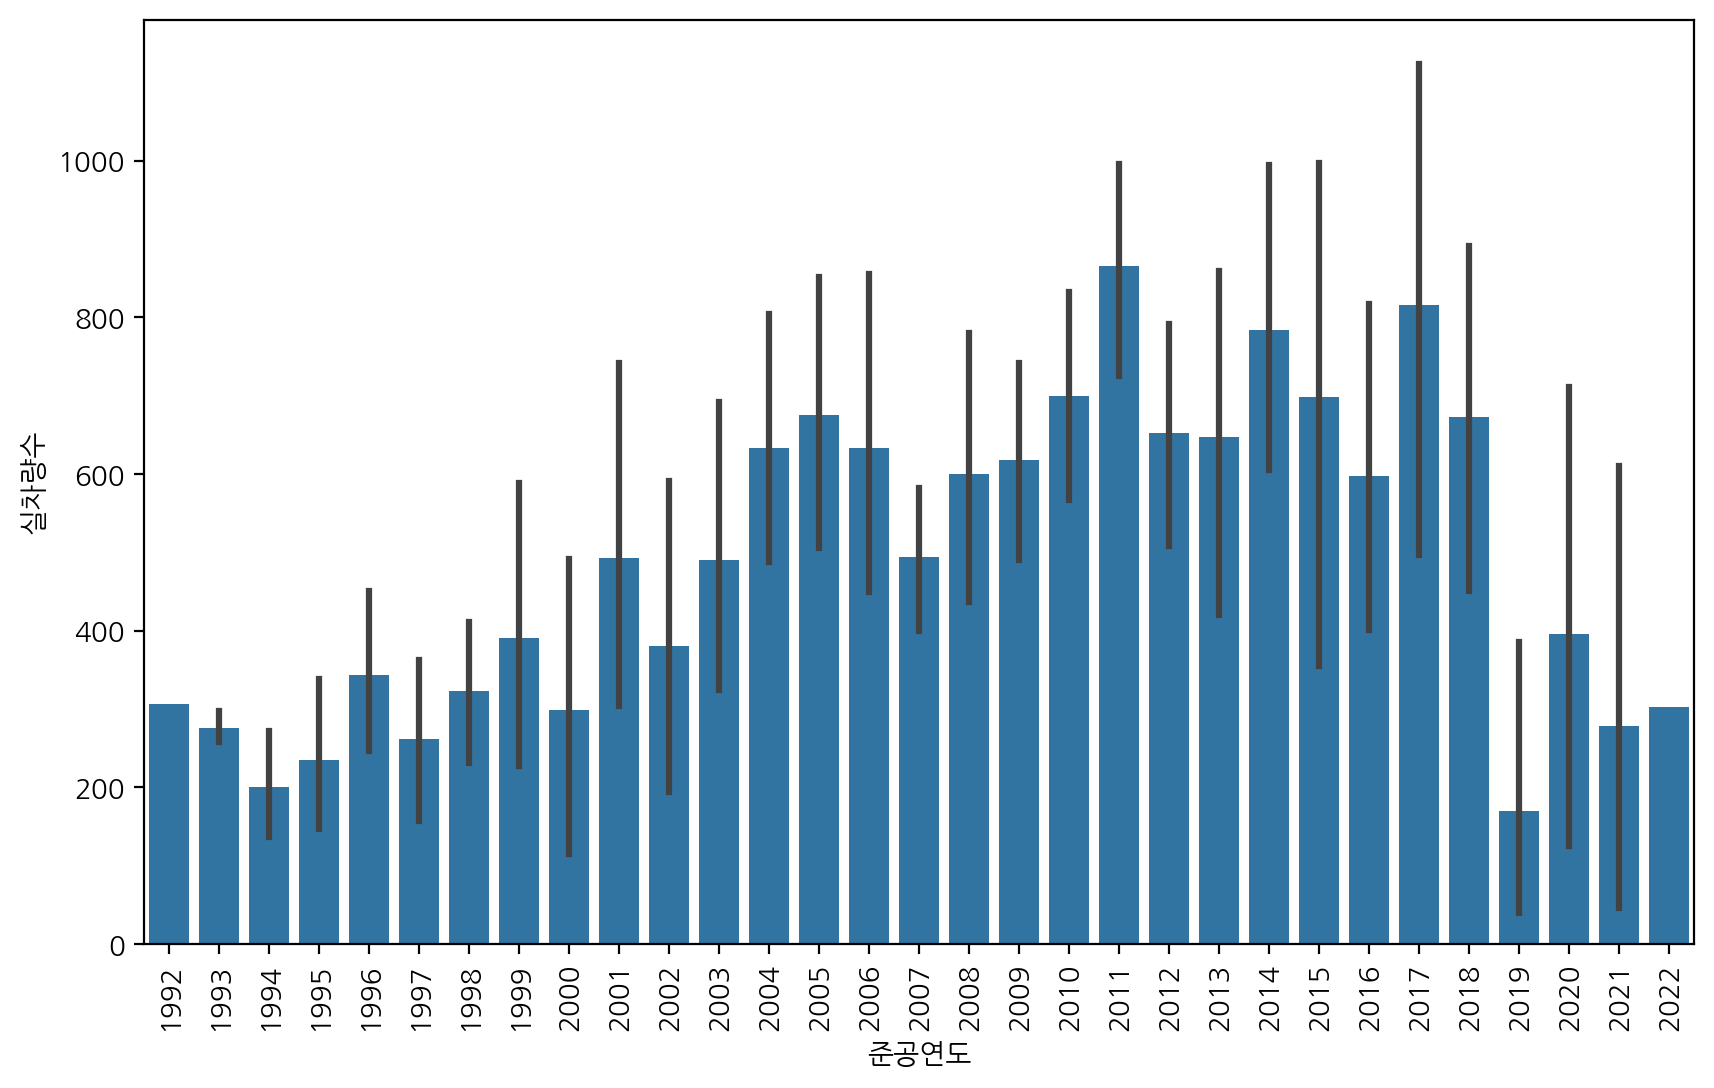

In [361]:
cate_bi('준공연도')

#### 3) 건물형태

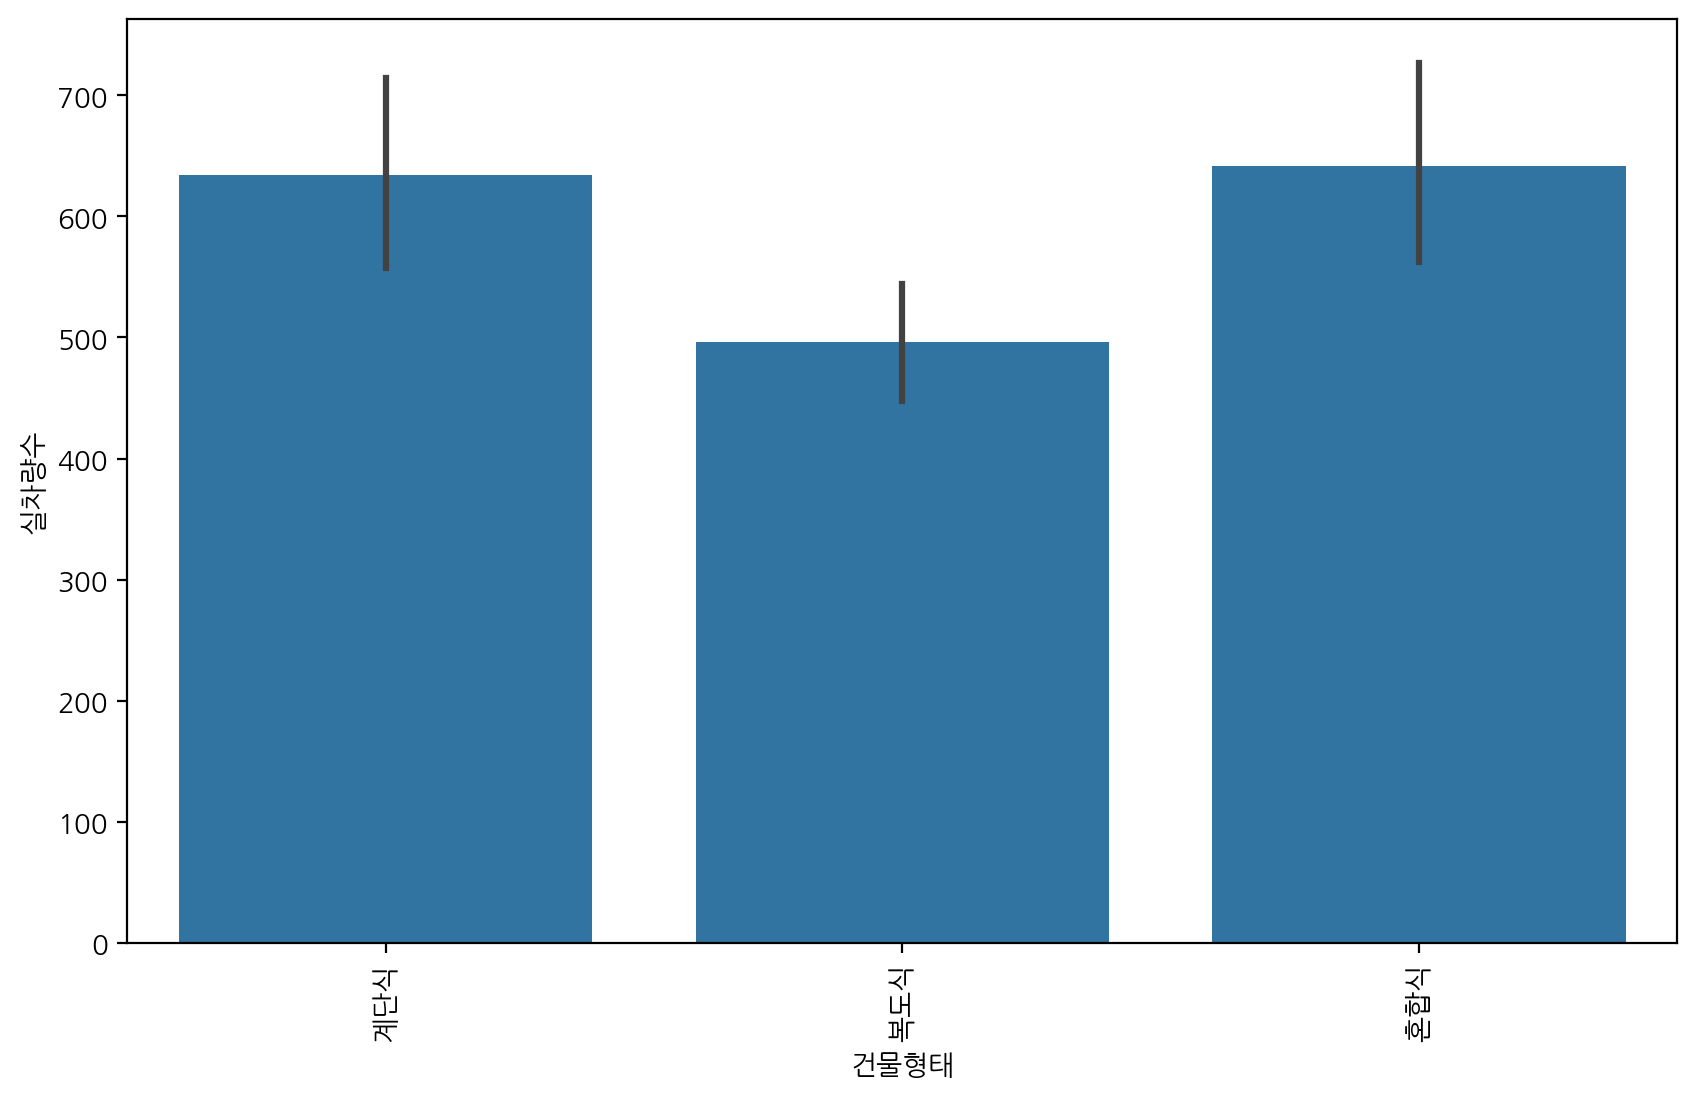

In [363]:
cate_bi('건물형태')

In [364]:
S = apart.loc[apart['건물형태'] == '계단식', '실차량수']
H = apart.loc[apart['건물형태'] == '복도식', '실차량수']
C = apart.loc[apart['건물형태'] == '혼합식', '실차량수']

spst.f_oneway(S, H, C)

F_onewayResult(statistic=6.07632088862142, pvalue=0.002552061140492482)

#### 4) 난방방식

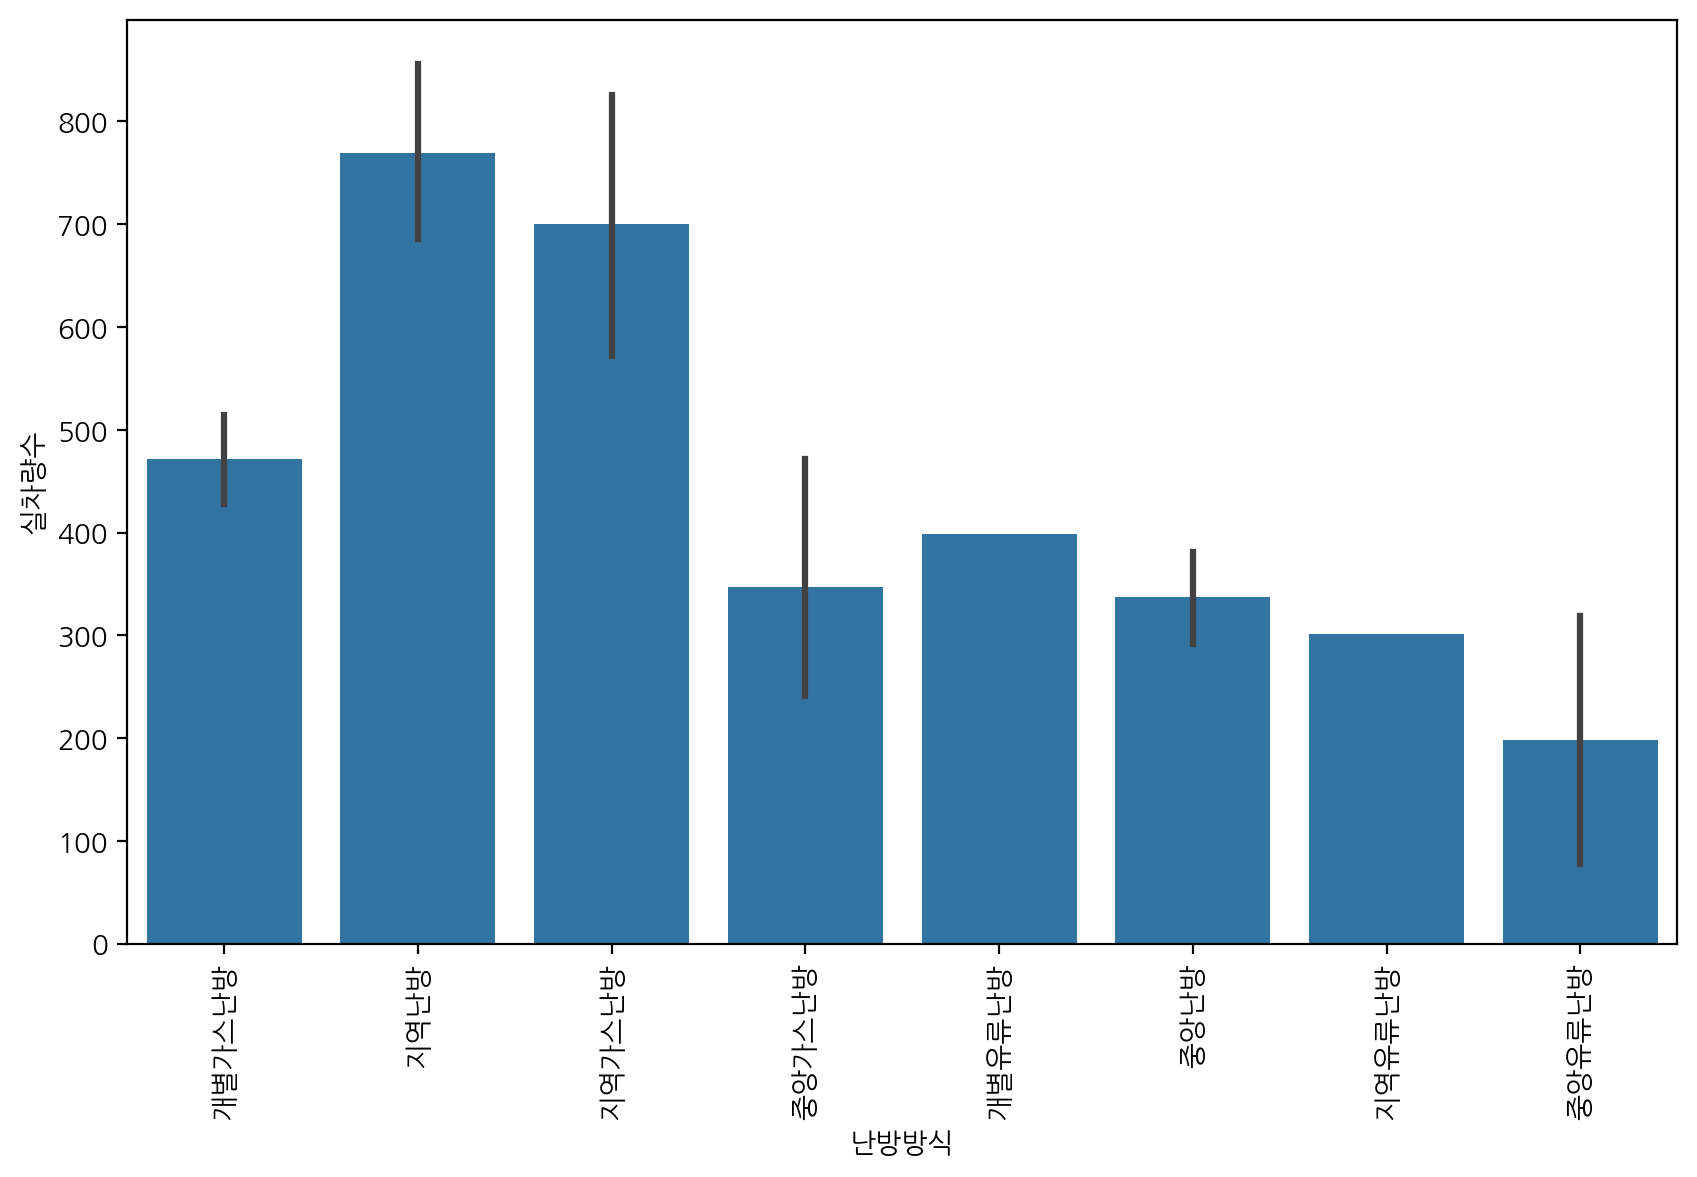

In [367]:
cate_bi('난방방식')

#### 5) 승강기설치여부

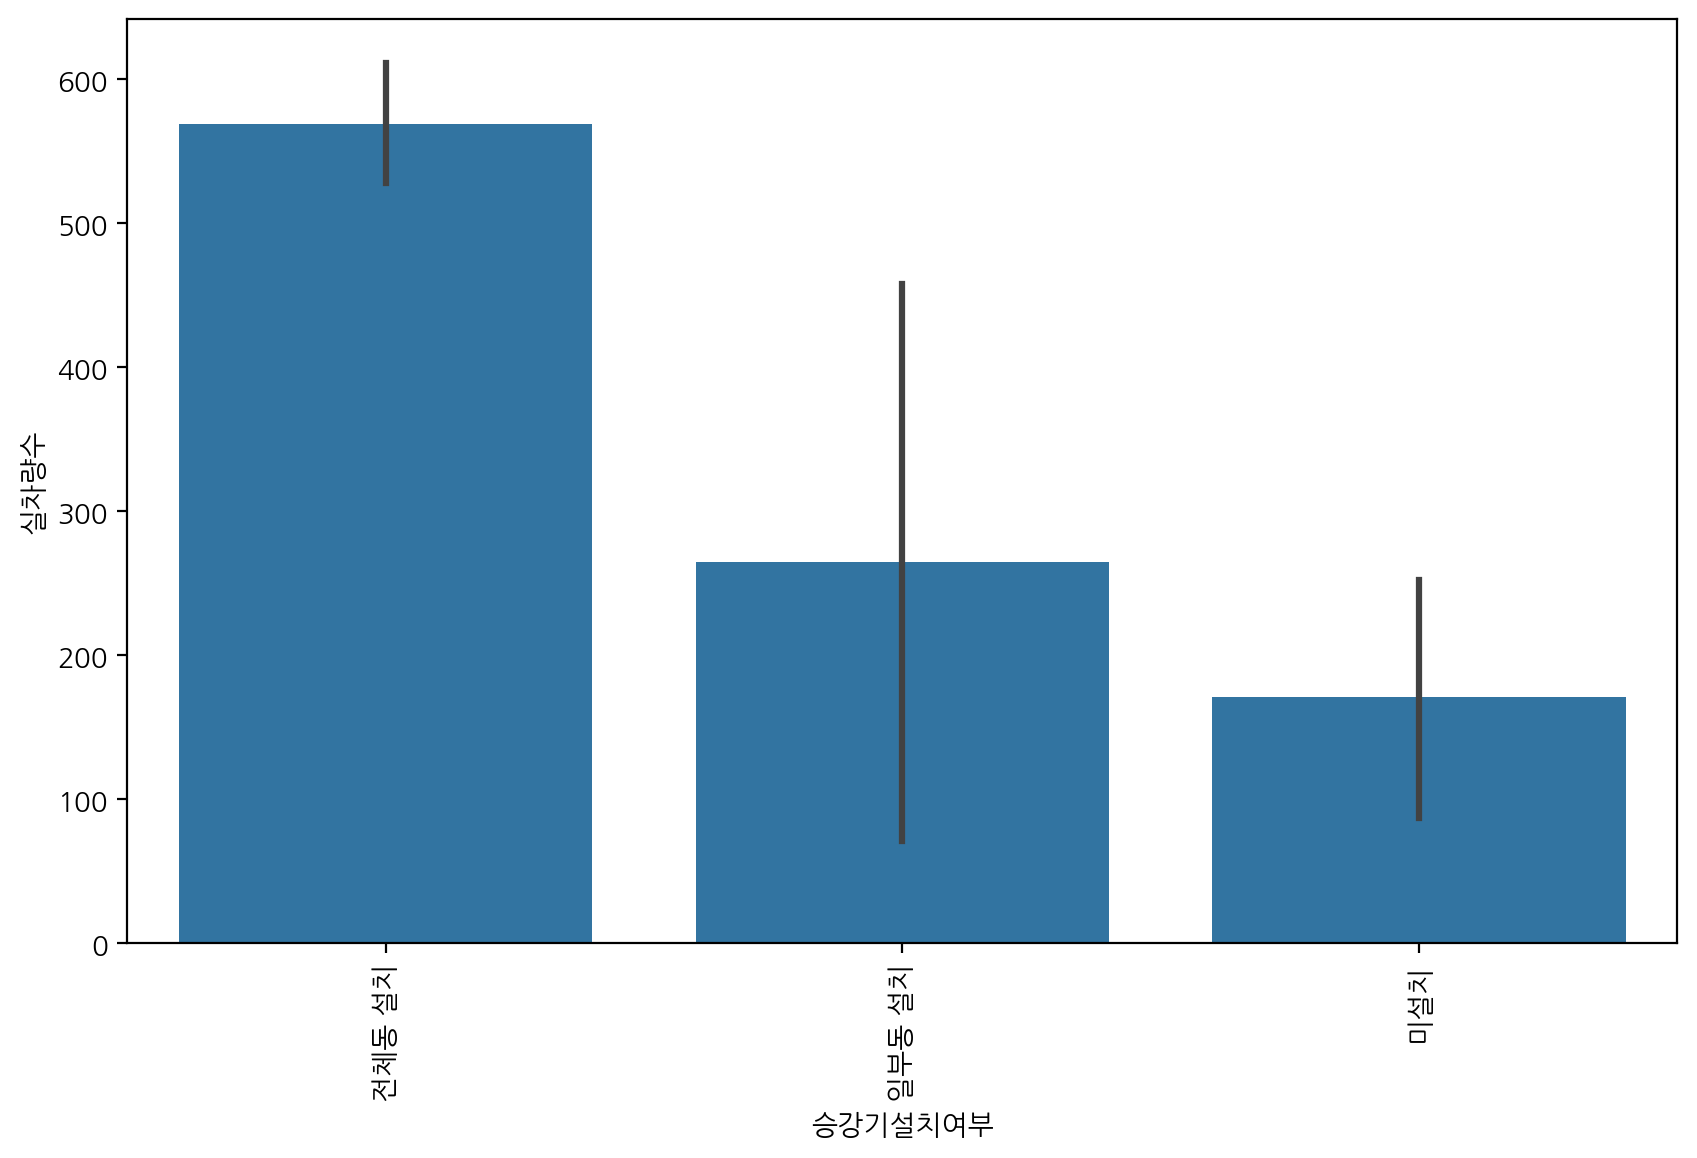

In [113]:
cate_bi('승강기설치여부')

## 5. 추가 전처리

- '난방방식', '승강기설치여부' 두 변수에 대해서 적은 수의 범주로 묶는 작업을 진행합니다.
- '단지코드'는 개별적인 값이므로 예측과 관련이 없으니 제거합니다.
- '지역' 변수는 지역별 특성을 고려하기에는 너무 세분화 되어 있고, 특징으로 통합하기 어려우므로 제거합니다.

### (1) 난방방식

- '난방방식' 변수의 값을 다음과 같이 변경하여 세 개의 범줏값만 갖게 합니다.
    - 개별가스난방 → 개별
    - 개별유류난방 → 개별
    - 지역난방 → 지역
    - 지역가스난방 → 지역
    - 지역유류난방 → 지역
    - 중앙가스난방 → 중앙
    - 중앙난방 → 중앙
    - 중앙유류난방 → 중앙

In [421]:
apart.loc[apart['난방방식'].str.contains('개별'), '난방방식'] = '개별'
apart.loc[apart['난방방식'].str.contains('지역'), '난방방식'] = '지역'
apart.loc[apart['난방방식'].str.contains('중앙'), '난방방식'] = '중앙'

In [118]:
apart.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
0,C0001,78,서울,2013,계단식,개별,전체동 설치,109,6023.7683,0,78,0,0,57598307.6923,645243.8462
1,C0002,35,서울,2013,복도식,개별,전체동 설치,35,1569.1668,35,0,0,0,63062000.0000,464533.7143
2,C0003,88,서울,2013,계단식,개별,전체동 설치,88,7180.1396,0,88,0,0,72190000.0000,586540.0000
3,C0004,477,서울,2014,복도식,지역,전체동 설치,943,47058.9273,0,150,216,111,91584727.4633,877880.2725
4,C0006,15,서울,2013,복도식,개별,전체동 설치,21,543.0268,15,0,0,0,54463150.0000,330212.0000


In [120]:
E = apart.loc[apart['난방방식'] == '개별', '실차량수']
R = apart.loc[apart['난방방식'] == '지역', '실차량수']
C = apart.loc[apart['난방방식'] == '중앙', '실차량수']

spst.f_oneway(E, R, C)

F_onewayResult(statistic=27.410830900547868, pvalue=9.091920049252099e-12)

### (2) 승강기설치여부

- '승강기설치여부' 변수의 값을 다음과 같이 변경하여 0, 1 값을 갖게 합니다.
    - 전체동 설치 → 1
    - 일부동 설치 → 0
    - 미설치 → 0

In [423]:
apart['승강기설치여부'] = np.where(apart['승강기설치여부'] == '전체동 설치', 1, 0)

In [125]:
apart.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
0,C0001,78,서울,2013,계단식,개별,1,109,6023.7683,0,78,0,0,57598307.6923,645243.8462
1,C0002,35,서울,2013,복도식,개별,1,35,1569.1668,35,0,0,0,63062000.0000,464533.7143
2,C0003,88,서울,2013,계단식,개별,1,88,7180.1396,0,88,0,0,72190000.0000,586540.0000
3,C0004,477,서울,2014,복도식,지역,1,943,47058.9273,0,150,216,111,91584727.4633,877880.2725
4,C0006,15,서울,2013,복도식,개별,1,21,543.0268,15,0,0,0,54463150.0000,330212.0000


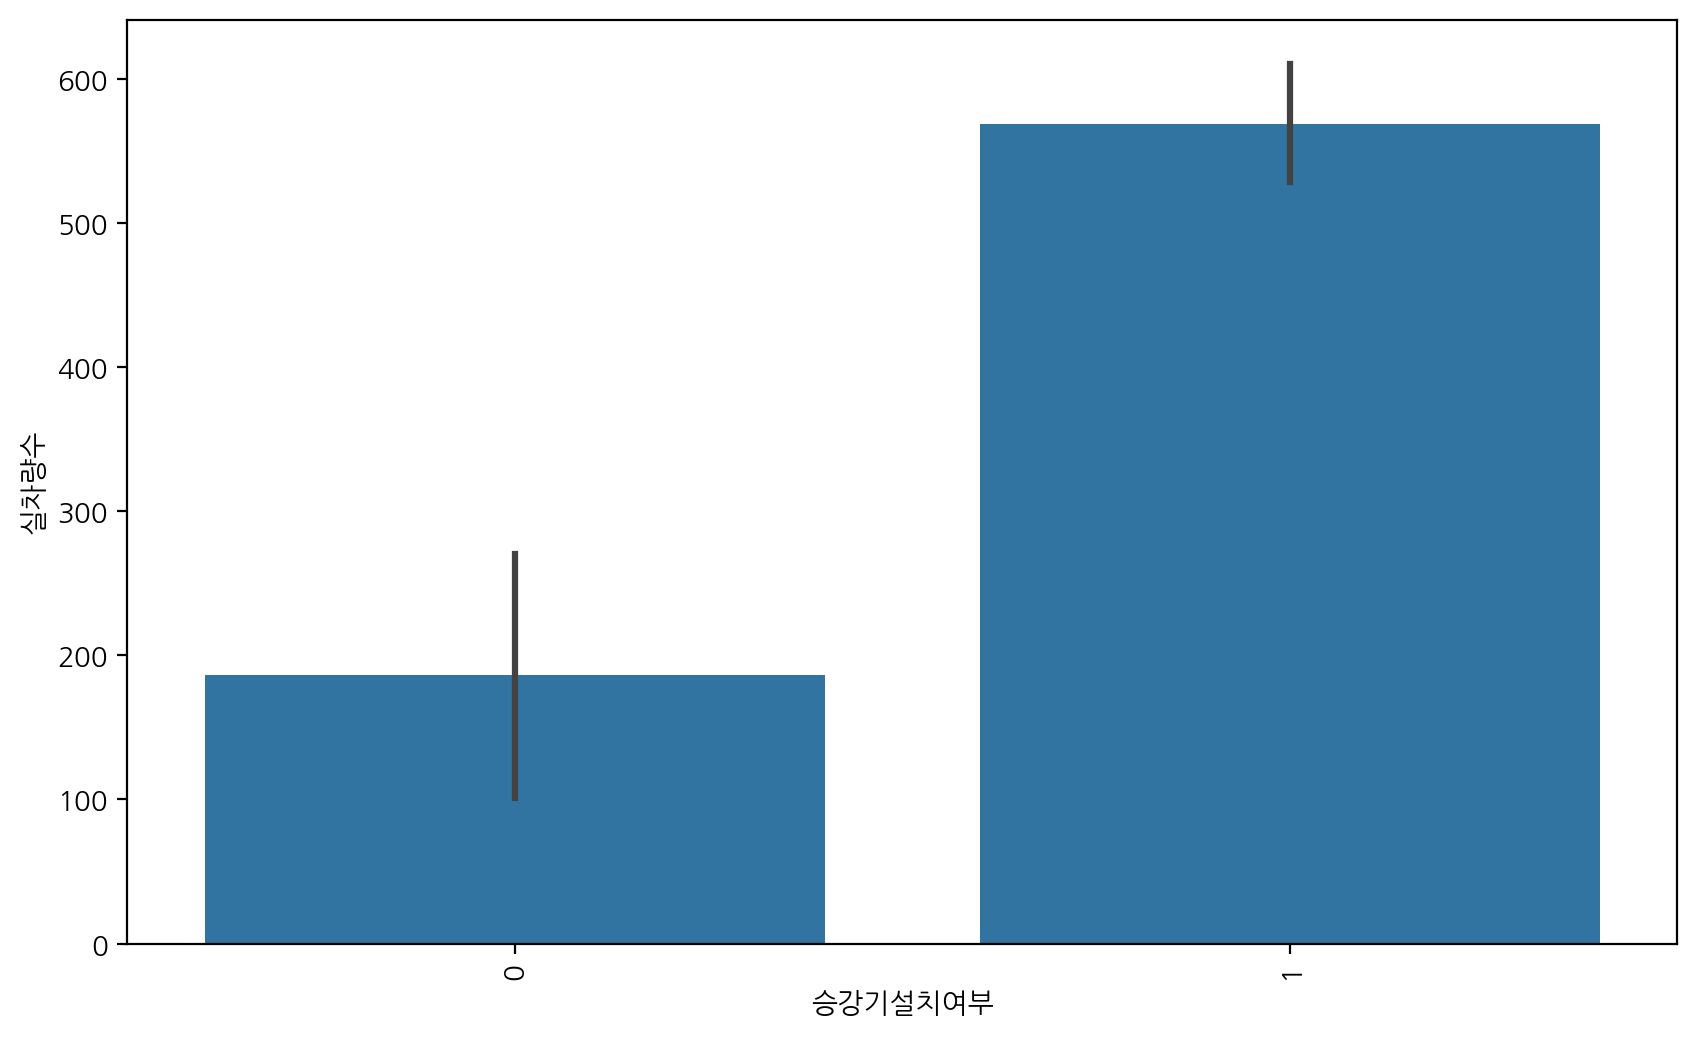

In [127]:
cate_bi('승강기설치여부')

In [128]:
N = apart.loc[apart['승강기설치여부'] == 0, '실차량수']
A = apart.loc[apart['승강기설치여부'] == 1, '실차량수']

spst.ttest_ind(N, A)

TtestResult(statistic=-3.5312443001283387, pvalue=0.0004701259556938628, df=343.0)

### (3) 건물형태

- '건물형태' 변수의 값을 다음과 같이 변경합니다.
    - 계단식 -> 계단식
    - 복도식 -> 복도식
    - 혼합식 -> 계단식

In [425]:
apart['건물형태'] = np.where(apart['건물형태'] == '복도식', '복도식', '계단식')

In [134]:
apart.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
0,C0001,78,서울,2013,계단식,개별,1,109,6023.7683,0,78,0,0,57598307.6923,645243.8462
1,C0002,35,서울,2013,복도식,개별,1,35,1569.1668,35,0,0,0,63062000.0000,464533.7143
2,C0003,88,서울,2013,계단식,개별,1,88,7180.1396,0,88,0,0,72190000.0000,586540.0000
3,C0004,477,서울,2014,복도식,지역,1,943,47058.9273,0,150,216,111,91584727.4633,877880.2725
4,C0006,15,서울,2013,복도식,개별,1,21,543.0268,15,0,0,0,54463150.0000,330212.0000


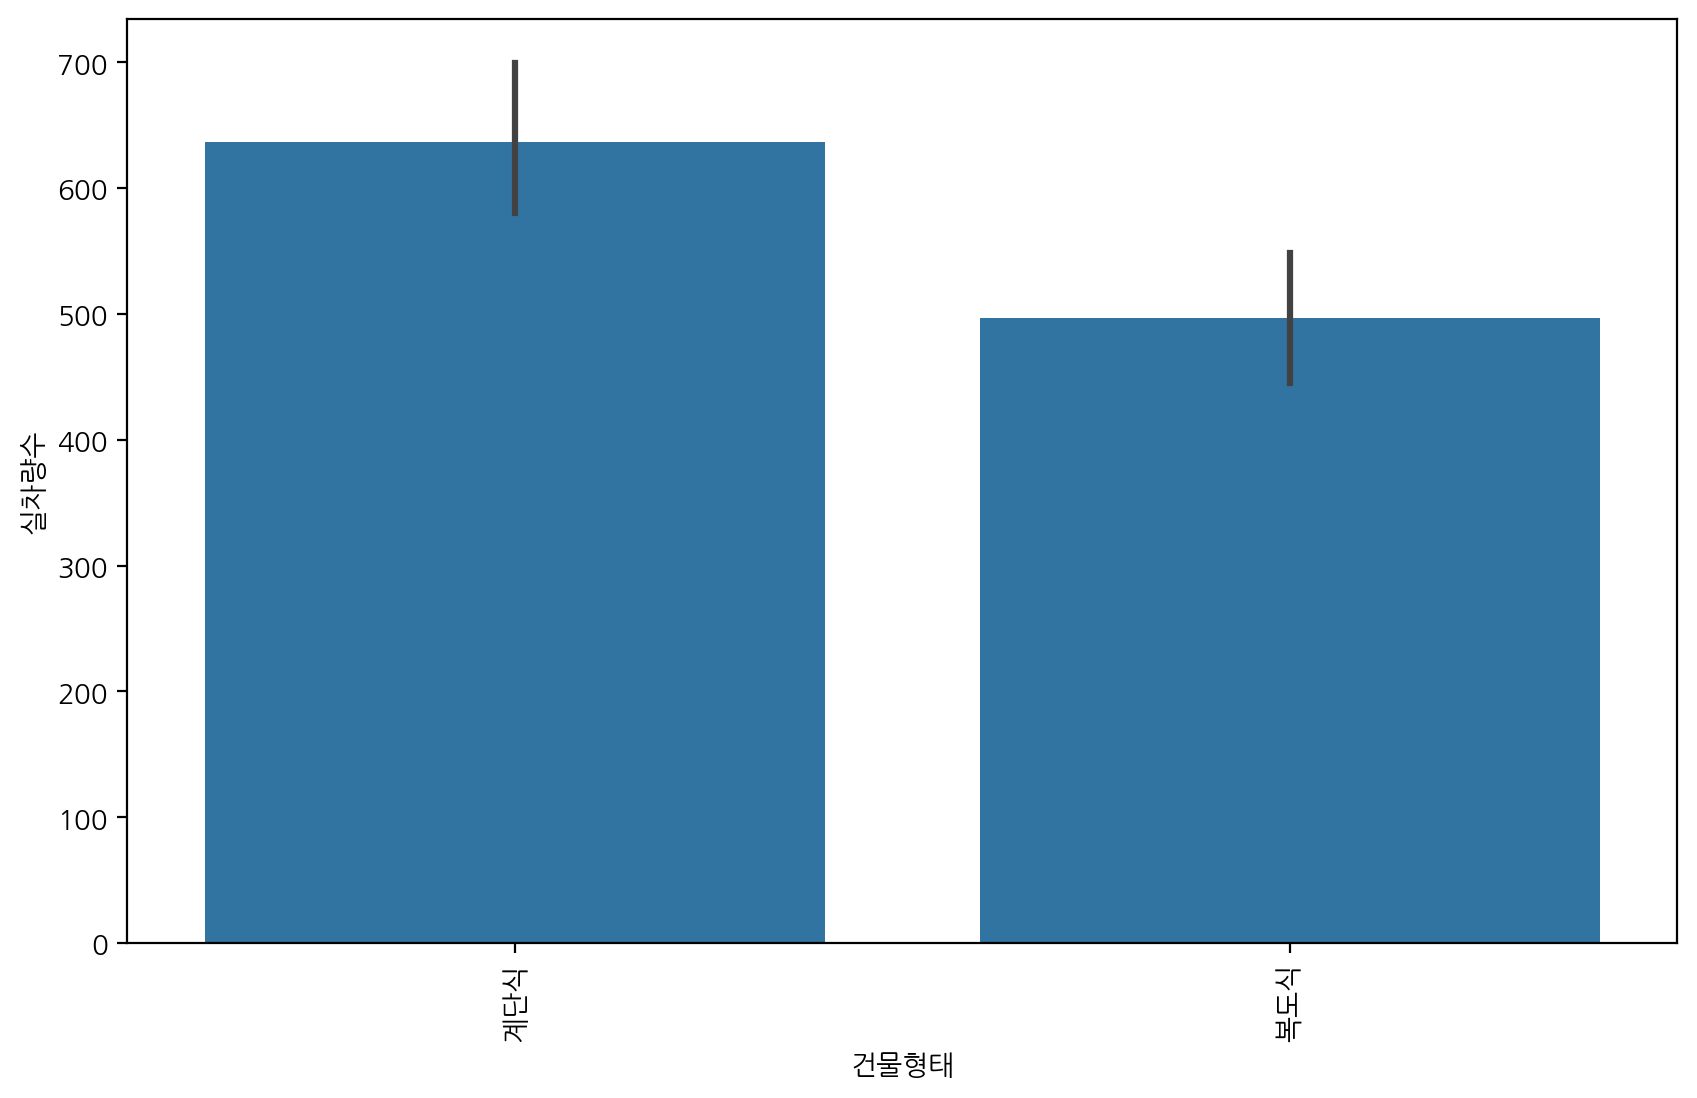

In [136]:
cate_bi('건물형태')

In [137]:
S = apart.loc[apart['건물형태'] == '계단식', '실차량수']
H = apart.loc[apart['건물형태'] == '복도식', '실차량수']

spst.ttest_ind(S, H)

TtestResult(statistic=3.4893954112284904, pvalue=0.0005472447102117833, df=343.0)

### (4) 준공연도

- '준공연도' 변수의 값을 다음과 같이 변경합니다.
    - 90년대
    - 00년대
    - 10년대 이후

In [141]:
apart['준공연도'] = np.where(apart['준공연도'] < 2000, '90년대', np.where(apart['준공연도'] < 2010, '00년대', '10년대 이후'))

In [143]:
apart.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료
0,C0001,78,서울,10년대 이후,계단식,개별,1,109,6023.7683,0,78,0,0,57598307.6923,645243.8462
1,C0002,35,서울,10년대 이후,복도식,개별,1,35,1569.1668,35,0,0,0,63062000.0000,464533.7143
2,C0003,88,서울,10년대 이후,계단식,개별,1,88,7180.1396,0,88,0,0,72190000.0000,586540.0000
3,C0004,477,서울,10년대 이후,복도식,지역,1,943,47058.9273,0,150,216,111,91584727.4633,877880.2725
4,C0006,15,서울,10년대 이후,복도식,개별,1,21,543.0268,15,0,0,0,54463150.0000,330212.0000


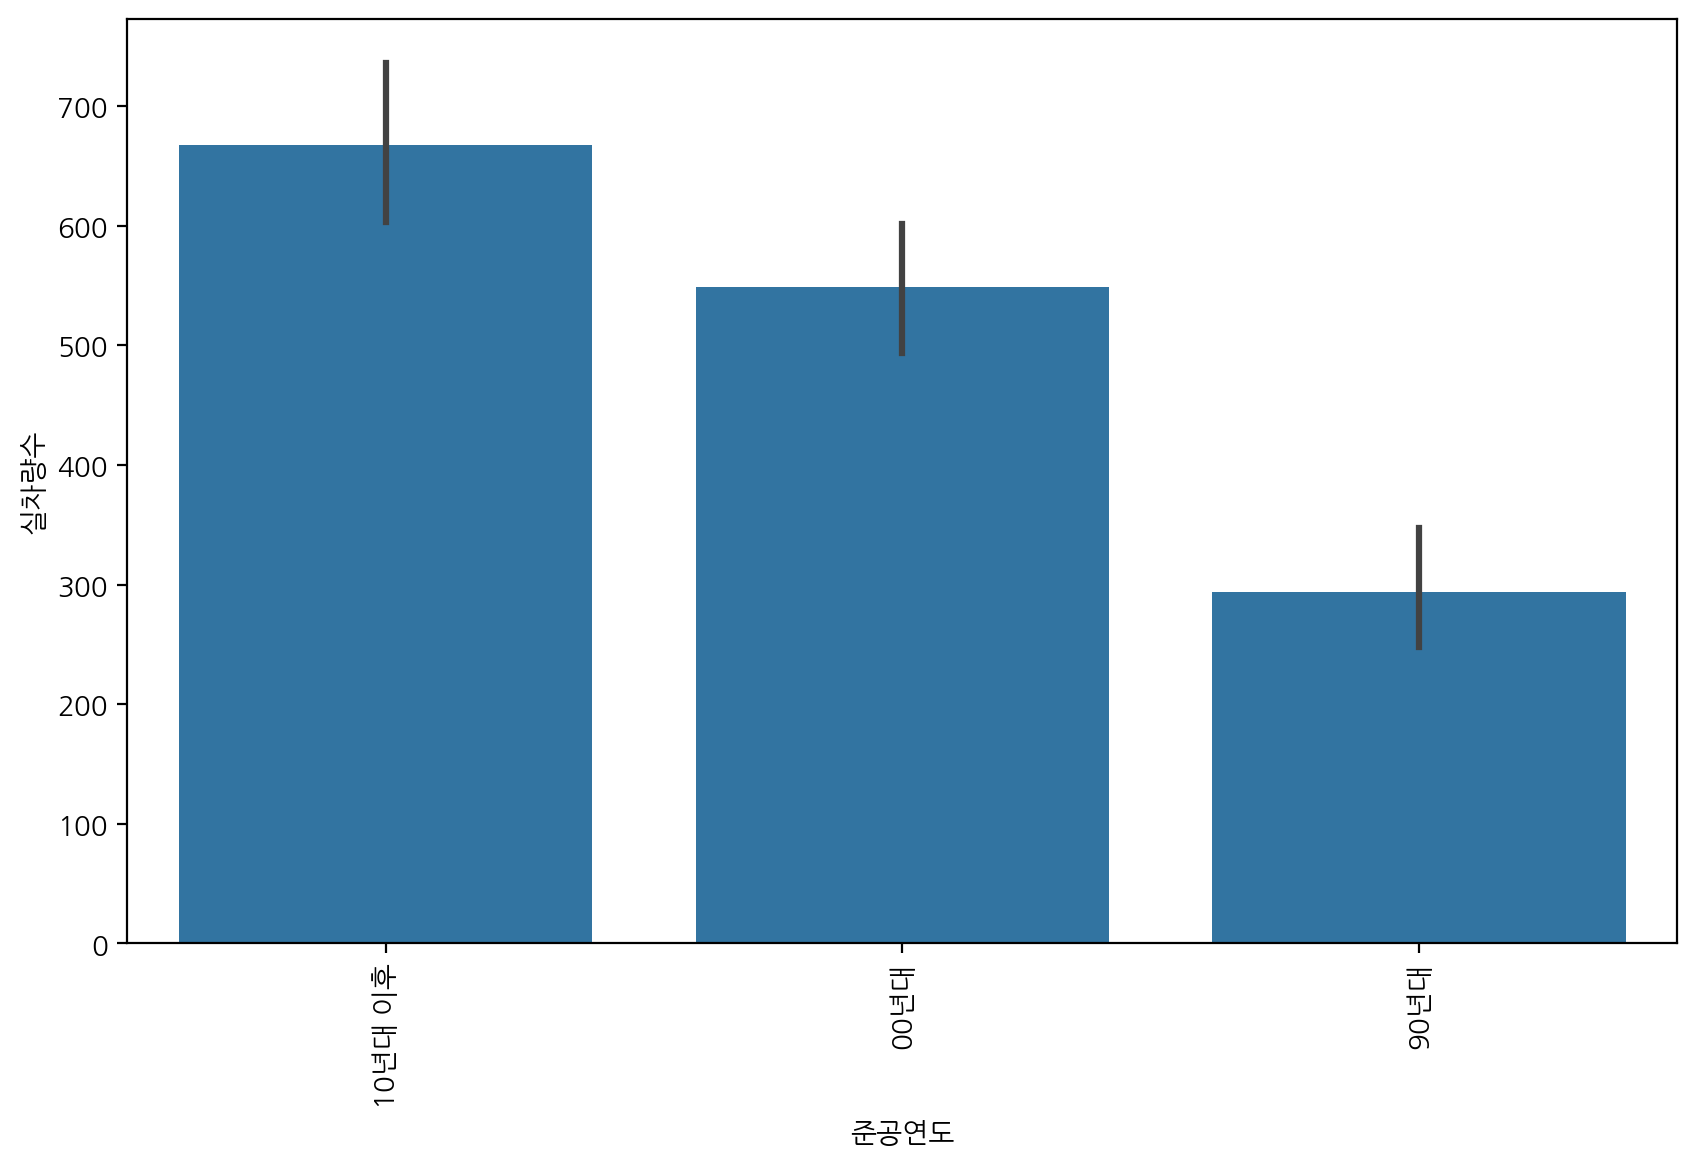

In [145]:
cate_bi('준공연도')

In [147]:
N = apart.loc[apart['준공연도'] == '90년대', '실차량수']
Z = apart.loc[apart['준공연도'] == '00년대', '실차량수']
O = apart.loc[apart['준공연도'] == '10년대 이후', '실차량수']

spst.f_oneway(N, Z, O)

F_onewayResult(statistic=24.196937074171714, pvalue=1.4840622048514055e-10)

### (5) 숫자형 변수 → 범주형 변수 -> 실차량수

- 숫자형 변수를 범주형 변수로 변환하여 사용

In [226]:
apart['가격대'] = pd.cut(apart['임대료'], 
                         bins=[-np.inf, 100000, 200000, 300000, 400000, 500000, np.inf], 
                         labels=['-100k', '100-200k', '200-300k', '300-400k', '400-500k','500k-'])

In [152]:
q = apart.loc[apart['가격대'] == '-100k', '실차량수']
w = apart.loc[apart['가격대'] == '100-200k', '실차량수']
e = apart.loc[apart['가격대'] == '200-300k', '실차량수']
r = apart.loc[apart['가격대'] == '300-400k', '실차량수']
t = apart.loc[apart['가격대'] == '400-500k', '실차량수']
y = apart.loc[apart['가격대'] == '500k-', '실차량수']

spst.f_oneway(q,w,e,r,t,y)

F_onewayResult(statistic=11.662148117731421, pvalue=2.0564055078294126e-10)

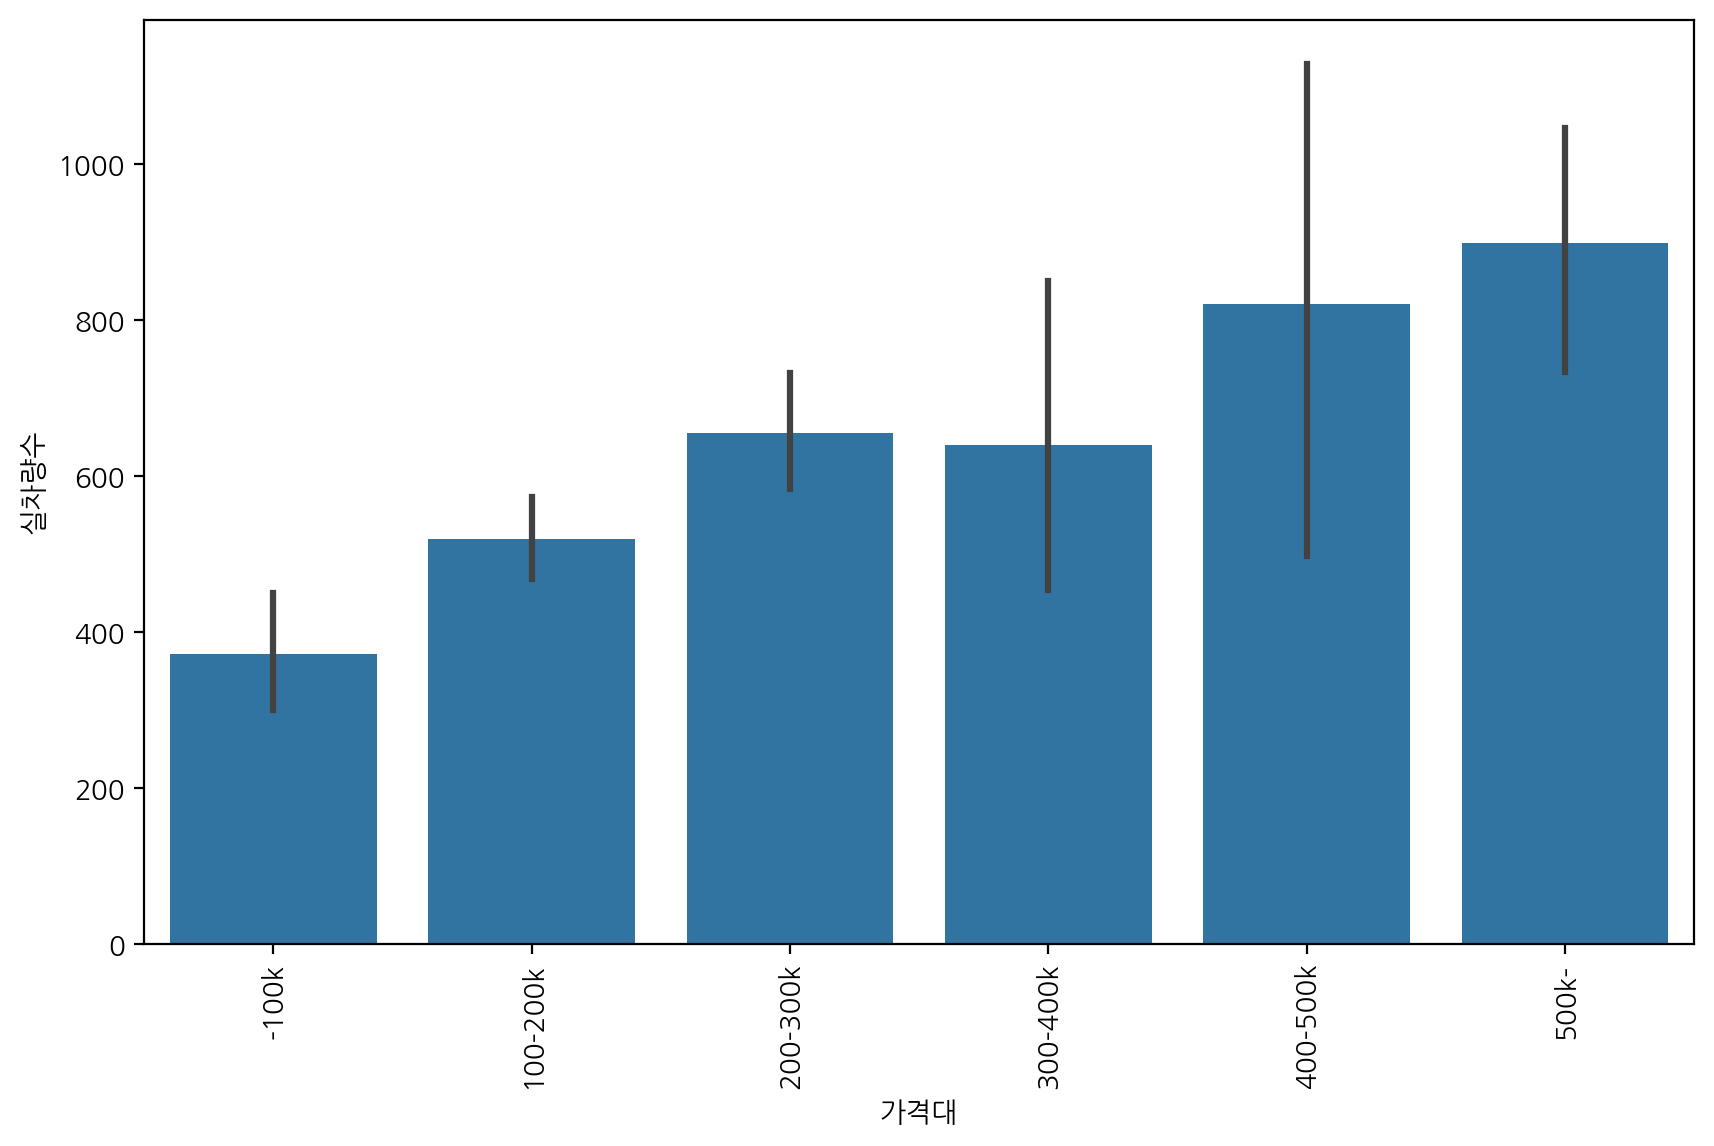

In [154]:
cate_bi('가격대')

In [427]:
# 범위 고려
apart['가격대'] = pd.cut(apart['임대료'], 
                         bins=[-np.inf, 100000, 200000, 400000, np.inf], 
                         labels=['-100k', '100-200k', '200-400k', '400k-'])

In [158]:
q = apart.loc[apart['가격대'] == '-100k', '실차량수']
w = apart.loc[apart['가격대'] == '100-200k', '실차량수']
e = apart.loc[apart['가격대'] == '200-400k', '실차량수']
r = apart.loc[apart['가격대'] == '400k-', '실차량수']

spst.f_oneway(q,w,e,r)

F_onewayResult(statistic=19.424779066553878, pvalue=1.1924790424784858e-11)

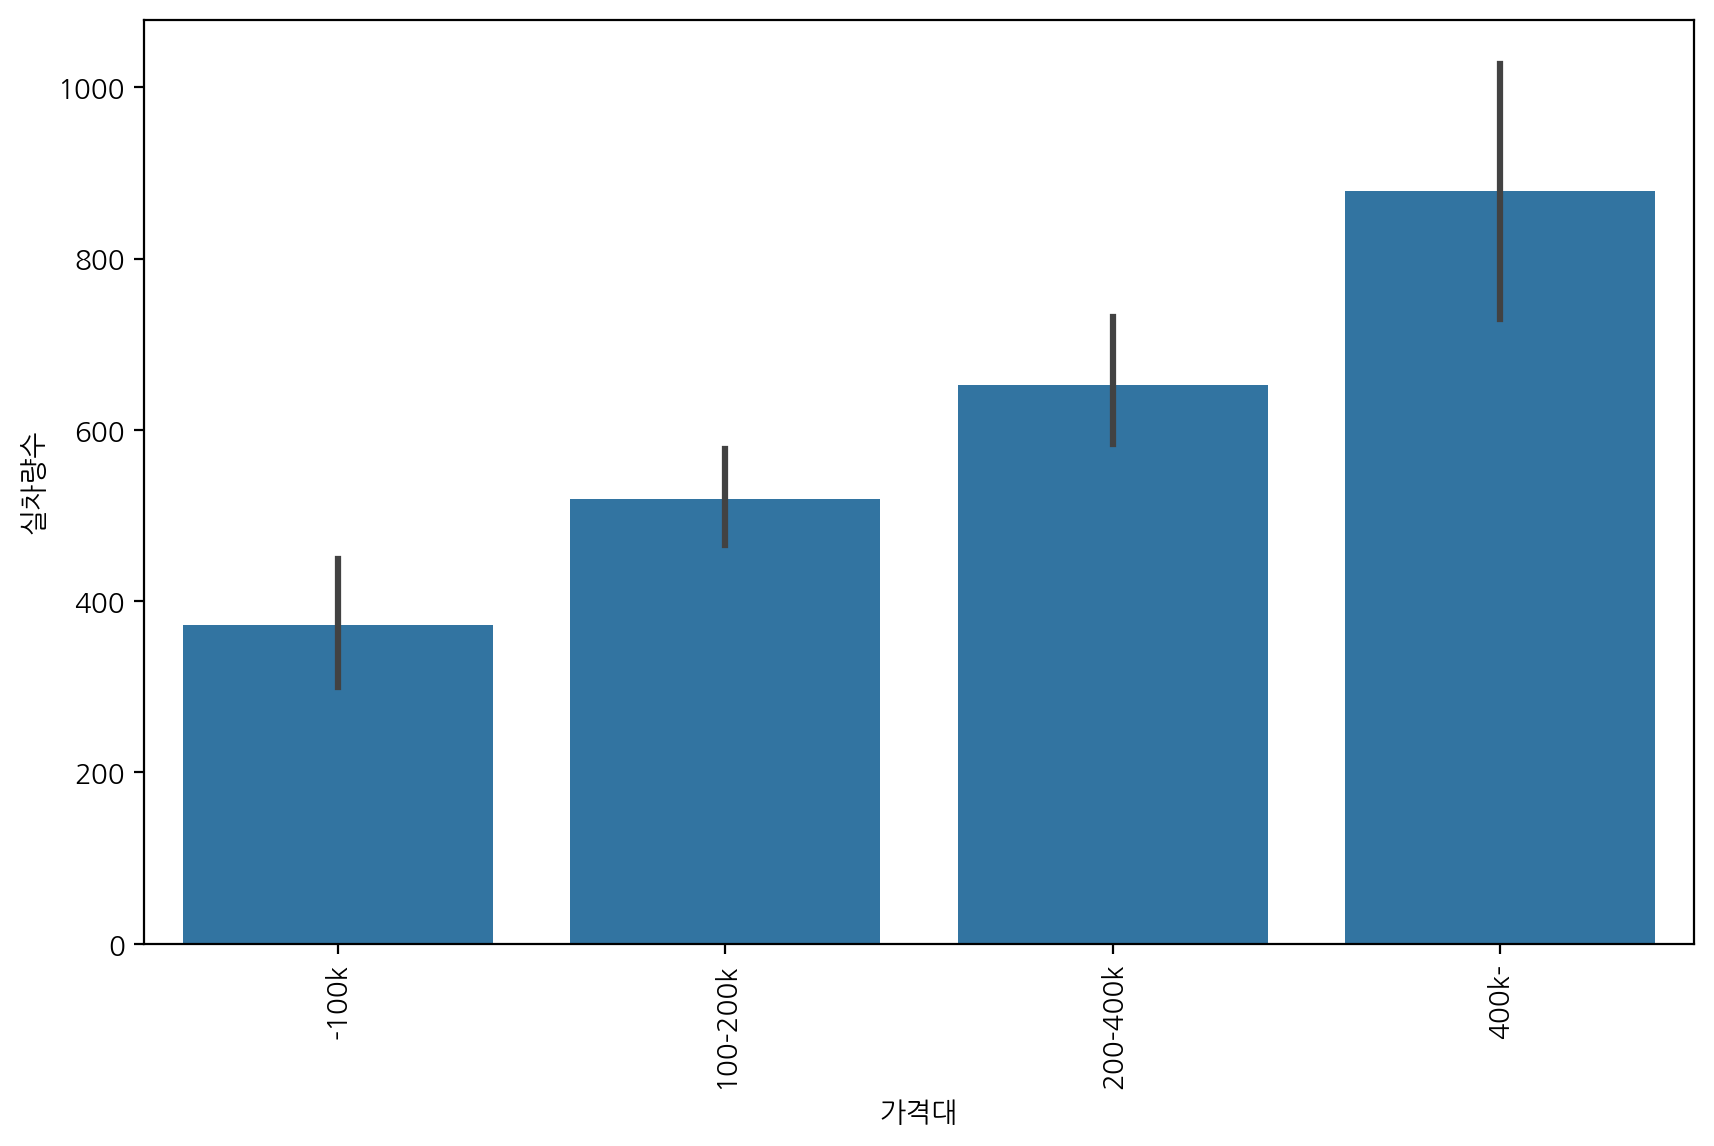

In [160]:
cate_bi('가격대')

In [228]:
# 범위 고려
apart['세대수범주'] = pd.cut(apart['총세대수'], 
                         bins=[-np.inf, 50, 100, 300,500,1000,np.inf], 
                         labels=['-50','50-100','100-300', '300-500','500-1000','1000-'])

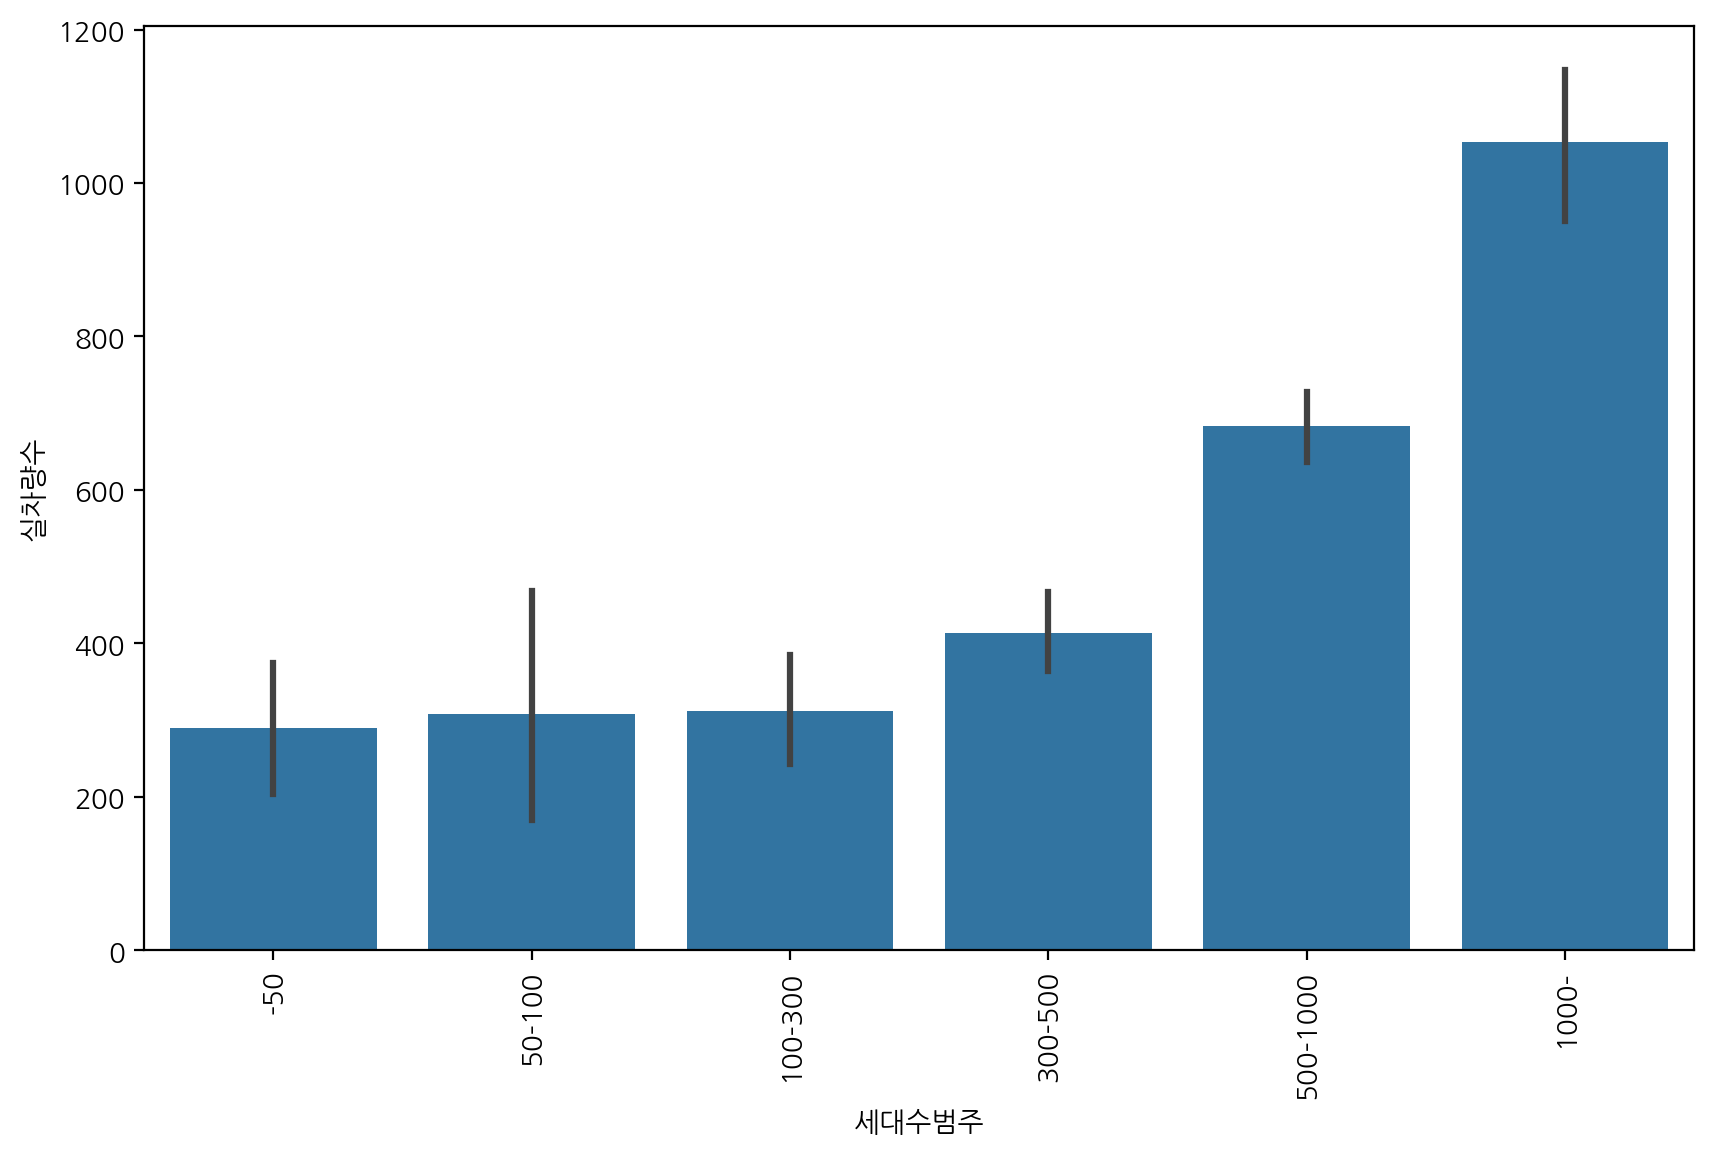

In [187]:
cate_bi('세대수범주')

In [429]:
# 범위 고려
apart['세대수범주'] = pd.cut(apart['총세대수'], 
                         bins=[-np.inf, 300, 500, 1000, np.inf], 
                         labels=['-300', '300-500','500-1000','1000-'])

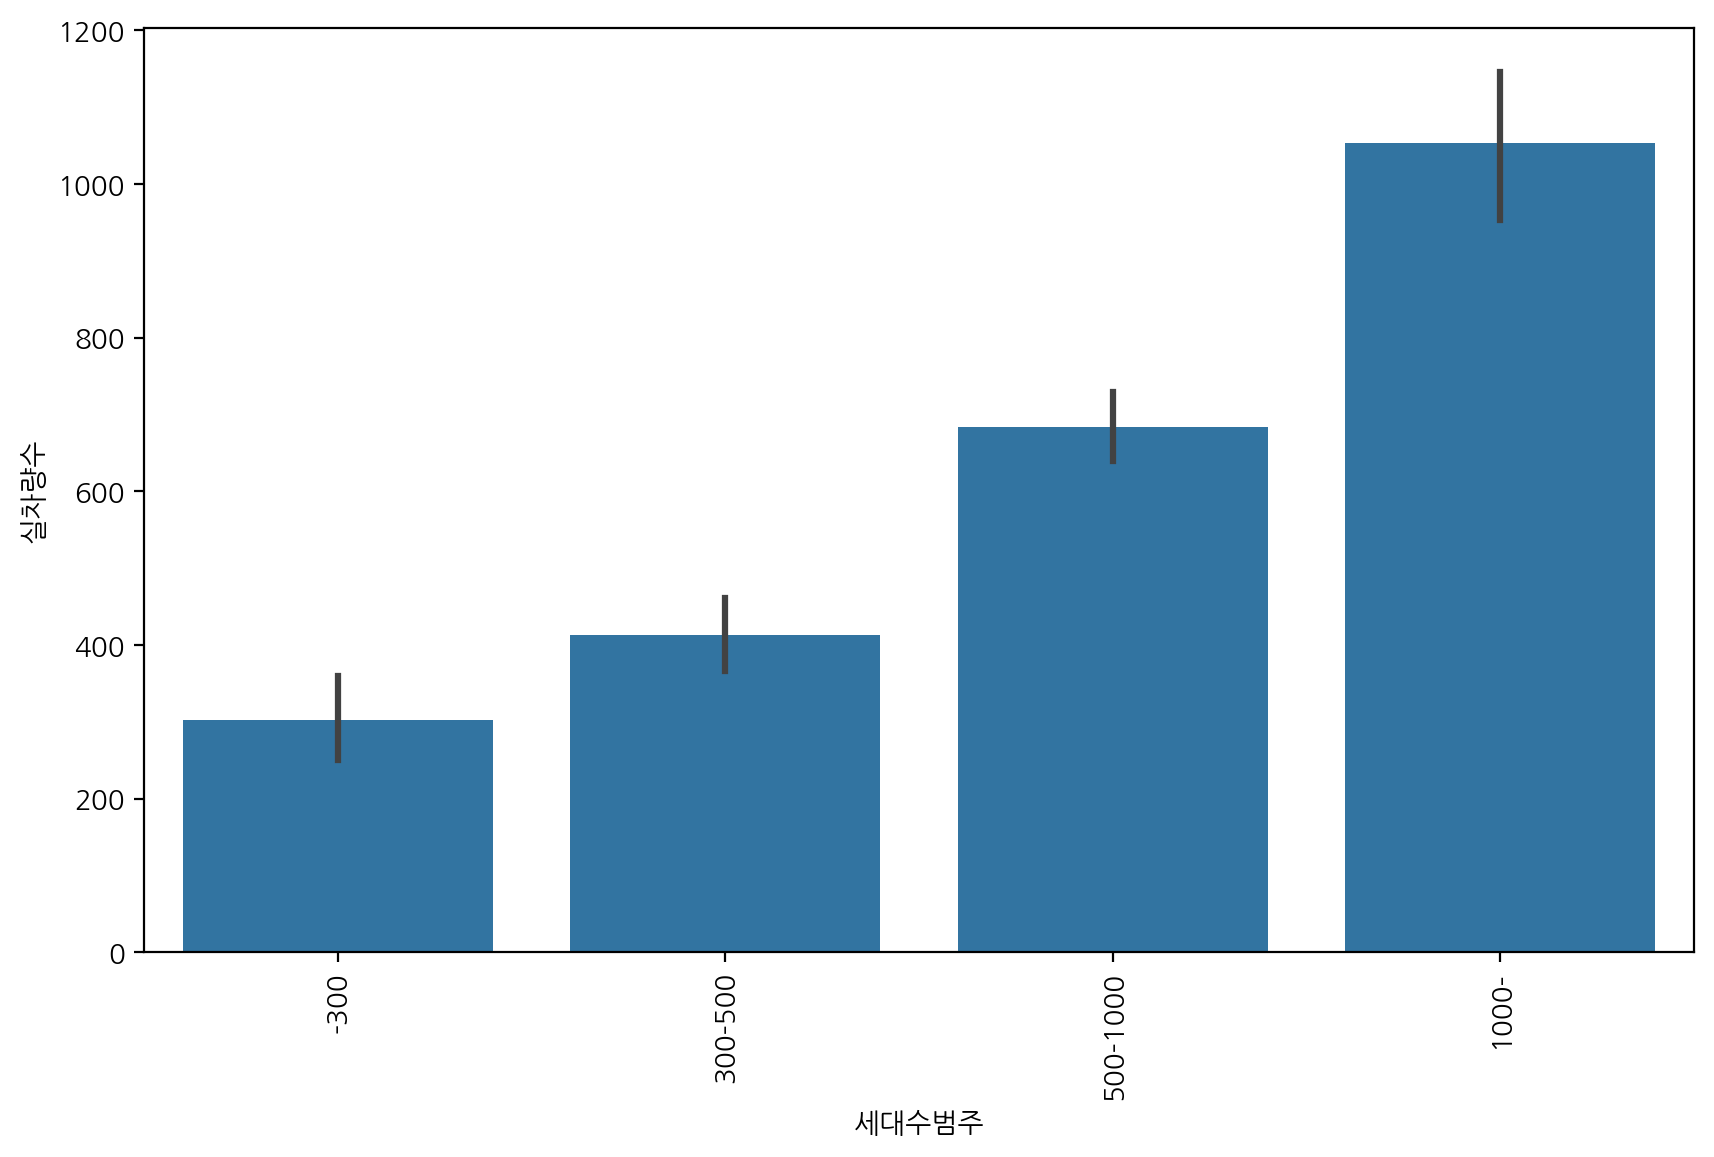

In [206]:
cate_bi('세대수범주')

### (6) 단지코드, 지역 제거

- '단지코드', '지역' 변수를 제거합니다.

In [431]:
drop_cols = ['단지코드', '지역']

apart.drop(columns=drop_cols, inplace=True)

- 최종 데이터를 확인합니다.

In [230]:
apart.head()

,총세대수,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,면적10_40,면적40_60,면적60_80,면적80_200,임대보증금,임대료,가격대,세대수범주
0,78,10년대 이후,계단식,개별,1,109,6023.7683,0,78,0,0,57598307.6923,645243.8462,500k-,50-100
1,35,10년대 이후,복도식,개별,1,35,1569.1668,35,0,0,0,63062000.0000,464533.7143,400-500k,-50
2,88,10년대 이후,계단식,개별,1,88,7180.1396,0,88,0,0,72190000.0000,586540.0000,500k-,50-100
3,477,10년대 이후,복도식,지역,1,943,47058.9273,0,150,216,111,91584727.4633,877880.2725,500k-,300-500
4,15,10년대 이후,복도식,개별,1,21,543.0268,15,0,0,0,54463150.0000,330212.0000,300-400k,-50


## 6. 데이터 셋 저장

- joblib.dump() 함수를 사용하여 최종 데이터 셋을 파일로 저장합니다.
- 파일 이름은 base_data2.pkl로 합니다.

In [433]:
# 파일로 저장
joblib.dump(apart, path+'base_data2.pkl')

['base_data2.pkl']